In [2]:
import sys
!{sys.executable} -m pip install --quiet seaborn scipy scikit-learn numpy pandas matplotlib umap-learn hdbscan tslearn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Arc Clustering
**Shapes of Stories: Visualising the Narrative and Structural Drift in Hollywood Screenwriting**

This notebook takes the 20-point emotional arc vectors produced by the arc-generation stage and groups films into families of shared narrative shape. The method follows Reagan et al. (2016), "The emotional arcs of stories are dominated by six basic shapes," *EPJ Data Science* 5:31. The clustering is hierarchical and agglomerative — it finds structure in the data rather than imposing it. Genre and decade are not inputs to the clustering; they enter only at the interpretation stage, as lenses for reading what the clusters mean.

## Section 1: Load and Validate

We load the arc vectors, derive two convenience columns (decade and primary genre), and plot a random sample of 12 arcs to visually confirm the data looks like plausible sentiment trajectories before any analysis begins. This is a sanity check, not analysis — if the arcs look like noise or flat lines, something went wrong upstream.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import pearsonr, chi2_contingency
from sklearn.metrics import silhouette_score

# ── paths ────────────────────────────────────────────────────────────────────
ARC_CSV      = "../data/processed/emotional_arcs.csv"
OUTPUT_DIR   = "../thesis-outputs/"

ARC_COLS = [f"w{str(i).zfill(2)}" for i in range(1, 21)]  # w01 … w20

# ── load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(ARC_CSV)

# ── derive decade ─────────────────────────────────────────────────────────────
def year_to_decade(year):
    if   1980 <= year <= 1989: return "1980s"
    elif 1990 <= year <= 1999: return "1990s"
    elif 2000 <= year <= 2009: return "2000s"
    elif 2010 <= year <= 2019: return "2010s"
    elif 2020 <= year <= 2025: return "2020s"
    else: return "Other"

df["decade"]        = df["year"].apply(year_to_decade)
df["primary_genre"] = df["genre"].str.split("|").str[0]

# ── validate ──────────────────────────────────────────────────────────────────
print(f"Corpus shape: {df.shape[0]} films × {df.shape[1]} columns")
print(f"Arc vector columns present: {all(c in df.columns for c in ARC_COLS)}")
print(f"Missing values in arc vectors: {df[ARC_COLS].isnull().sum().sum()}")

print("\nDecade distribution:")
decade_counts = df["decade"].value_counts().sort_index()
for decade, count in decade_counts.items():
    pct = count / len(df) * 100
    print(f"  {decade}: {count:4d}  ({pct:.1f}%)")

print("\nPrimary genre distribution (top 15):")
genre_counts = df["primary_genre"].value_counts().head(15)
for genre, count in genre_counts.items():
    pct = count / len(df) * 100
    print(f"  {genre:<20s}: {count:4d}  ({pct:.1f}%)")

Corpus shape: 1627 films × 26 columns
Arc vector columns present: True
Missing values in arc vectors: 0

Decade distribution:
  1980s:  214  (13.2%)
  1990s:  287  (17.6%)
  2000s:  310  (19.1%)
  2010s:  569  (35.0%)
  2020s:  247  (15.2%)

Primary genre distribution (top 15):
  Drama               :  449  (27.6%)
  Comedy              :  299  (18.4%)
  Action              :  178  (10.9%)
  Horror              :  144  (8.9%)
  Adventure           :  114  (7.0%)
  Crime               :   86  (5.3%)
  Thriller            :   72  (4.4%)
  Science Fiction     :   59  (3.6%)
  Fantasy             :   48  (3.0%)
  Animation           :   41  (2.5%)
  Romance             :   35  (2.2%)
  Mystery             :   24  (1.5%)
  History             :   22  (1.4%)
  Family              :   20  (1.2%)
  War                 :   13  (0.8%)


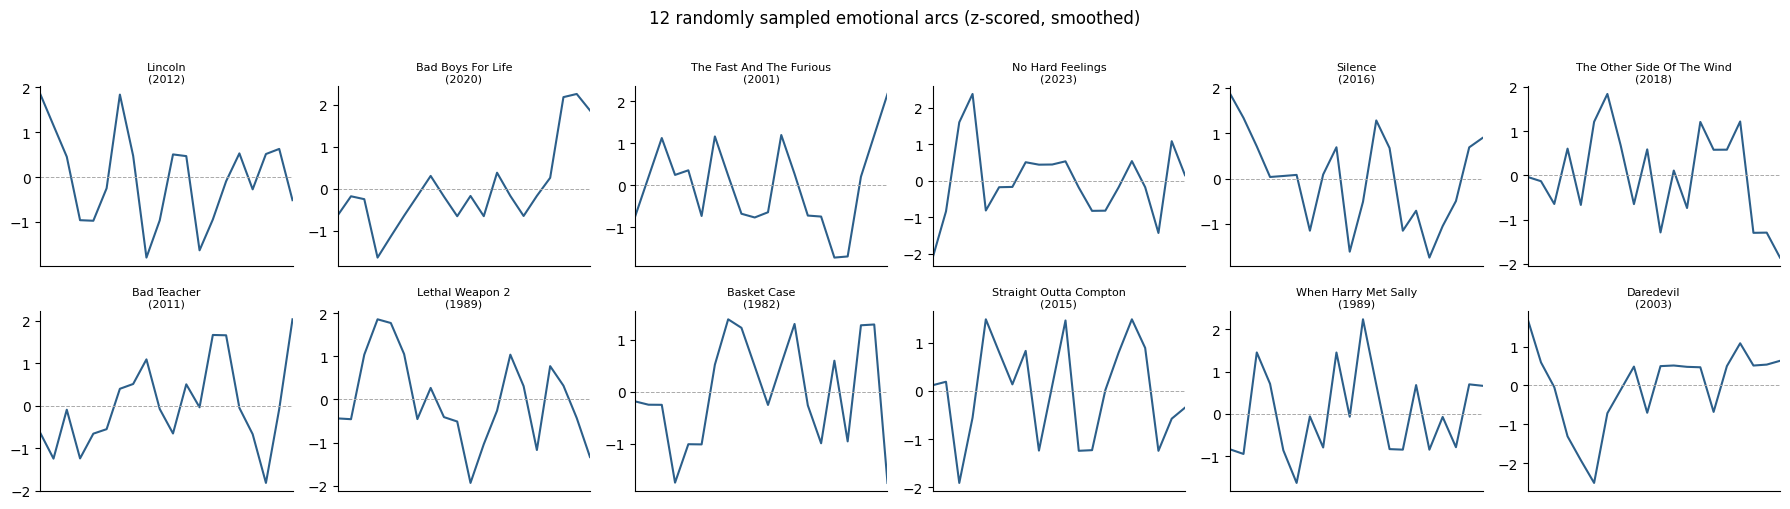

In [5]:
# ── plot 12 randomly sampled arcs ─────────────────────────────────────────────
rng = np.random.default_rng(seed=42)
sample_indices = rng.choice(len(df), size=12, replace=False)
sample_df = df.iloc[sample_indices]

x_positions = np.linspace(0, 1, 20)

fig, axes = plt.subplots(2, 6, figsize=(18, 5))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    arc_values = row[ARC_COLS].values.astype(float)
    ax.plot(x_positions, arc_values, color="#2C5F8A", linewidth=1.5)
    ax.axhline(0, color="#AAAAAA", linewidth=0.7, linestyle="--")
    ax.set_title(f"{row['title']}\n({int(row['year'])})", fontsize=8, pad=3)
    ax.set_xticks([])
    ax.set_xlim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("12 randomly sampled emotional arcs (z-scored, smoothed)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}sample_arcs.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 2: Build the Distance Matrix

Before we can cluster films by arc shape, we need a measure of how similar any two arcs are. We use the same distance function as Reagan et al.: the mean absolute distance, which averages the absolute difference between two arcs at each of the 20 time points. This is also known as city-block or L1 distance, normalised by arc length. A distance of 0 means two arcs are identical; larger values mean more different shapes.

As a cross-check, we also compute standard Euclidean distance and verify the two matrices are highly correlated (they should be, since both measure arc dissimilarity). We use the mean absolute distance version as the primary metric throughout, consistent with Reagan et al.

In [6]:
arc_matrix = df[ARC_COLS].values.astype(float)  # shape: (n_films, 20)

# Reagan et al. distance: mean absolute distance (L1 / cityblock, normalised by l=20)
condensed_mad = pdist(arc_matrix, metric="cityblock") / 20.0
dist_matrix   = squareform(condensed_mad)

print(f"Distance matrix shape: {dist_matrix.shape}")
print(f"Distance range: [{dist_matrix.min():.4f}, {dist_matrix.max():.4f}]")
print(f"Mean pairwise distance: {condensed_mad.mean():.4f}")

# ── sanity check: correlation with Euclidean distance ────────────────────────
condensed_euc = pdist(arc_matrix, metric="euclidean")

r, p_val = pearsonr(condensed_mad, condensed_euc)
print(f"\nPearson r between MAD and Euclidean distance matrices: {r:.4f} (p={p_val:.2e})")

if r < 0.95:
    print("  ⚠  WARNING: correlation below 0.95 — inspect arc vectors for anomalies.")
else:
    print("  ✓  Correlation above 0.95 — distance matrices are consistent.")

Distance matrix shape: (1627, 1627)
Distance range: [0.0000, 1.7853]
Mean pairwise distance: 1.0991

Pearson r between MAD and Euclidean distance matrices: 0.9414 (p=0.00e+00)
  ⚠  WARNING: correlation below 0.95 — inspect arc vectors for anomalies.


## Section 2b: Arc Space Visualisation (UMAP + HDBSCAN)

Before committing to any clustering method or number of clusters, it helps to look at the arc space directly. UMAP (Uniform Manifold Approximation and Projection) projects all 1,627 twenty-dimensional arc vectors into two dimensions while preserving local neighbourhood structure. If the arcs form discrete clumps in this projection, clustering will be meaningful. If they form a single continuous cloud, the data is telling us there are no natural arc families — only a spectrum — and the analytical argument should shift accordingly.

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is then run on the UMAP embedding. Unlike Ward linkage, it does not require you to specify k in advance, does not force every film into a cluster, and handles non-spherical cluster shapes. Films in low-density regions are labelled as noise (cluster -1) rather than being assigned to the nearest family.

In [17]:
import sys
!{sys.executable} -m pip install --quiet umap-learn hdbscan


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import umap
import hdbscan
from sklearn.decomposition import PCA

# ── Step 1: reduce to 50 PCA dims first (speeds up UMAP, removes noise dims) ─
pca_50 = PCA(n_components=min(50, arc_matrix.shape[1]), random_state=42)
arc_pca = pca_50.fit_transform(arc_matrix)
print(f"Variance explained by 50 PCs: {pca_50.explained_variance_ratio_.sum():.3f}")
print(f"Variance explained by first 2 PCs: {pca_50.explained_variance_ratio_[:2].sum():.3f}")

# ── Step 2: UMAP projection to 2D ────────────────────────────────────────────
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='manhattan',
    random_state=42
)
embedding = reducer.fit_transform(arc_pca)
df['umap_x'] = embedding[:, 0]
df['umap_y'] = embedding[:, 1]

# ── Step 3: HDBSCAN on the UMAP embedding ────────────────────────────────────
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=40,
    min_samples=10,
    metric='euclidean'
)
hdb_labels = clusterer.fit_predict(embedding)
df['hdb_cluster'] = hdb_labels

n_hdb_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise        = (hdb_labels == -1).sum()
print(f"\nHDBSCAN found {n_hdb_clusters} clusters")
print(f"Noise points (no cluster): {n_noise} ({n_noise/len(df)*100:.1f}%)")
print("\nCluster sizes:")
for label, count in sorted(pd.Series(hdb_labels).value_counts().items()):
    tag = 'noise' if label == -1 else f'cluster {label}'
    print(f"  {tag}: {count}")

/Users/derinsavasan/Desktop/parsons-spring/thesis/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Variance explained by 50 PCs: 1.000
Variance explained by first 2 PCs: 0.229


/Users/derinsavasan/Desktop/parsons-spring/thesis/.venv311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



HDBSCAN found 2 clusters
Noise points (no cluster): 568 (34.9%)

Cluster sizes:
  noise: 568
  cluster 0: 934
  cluster 1: 125


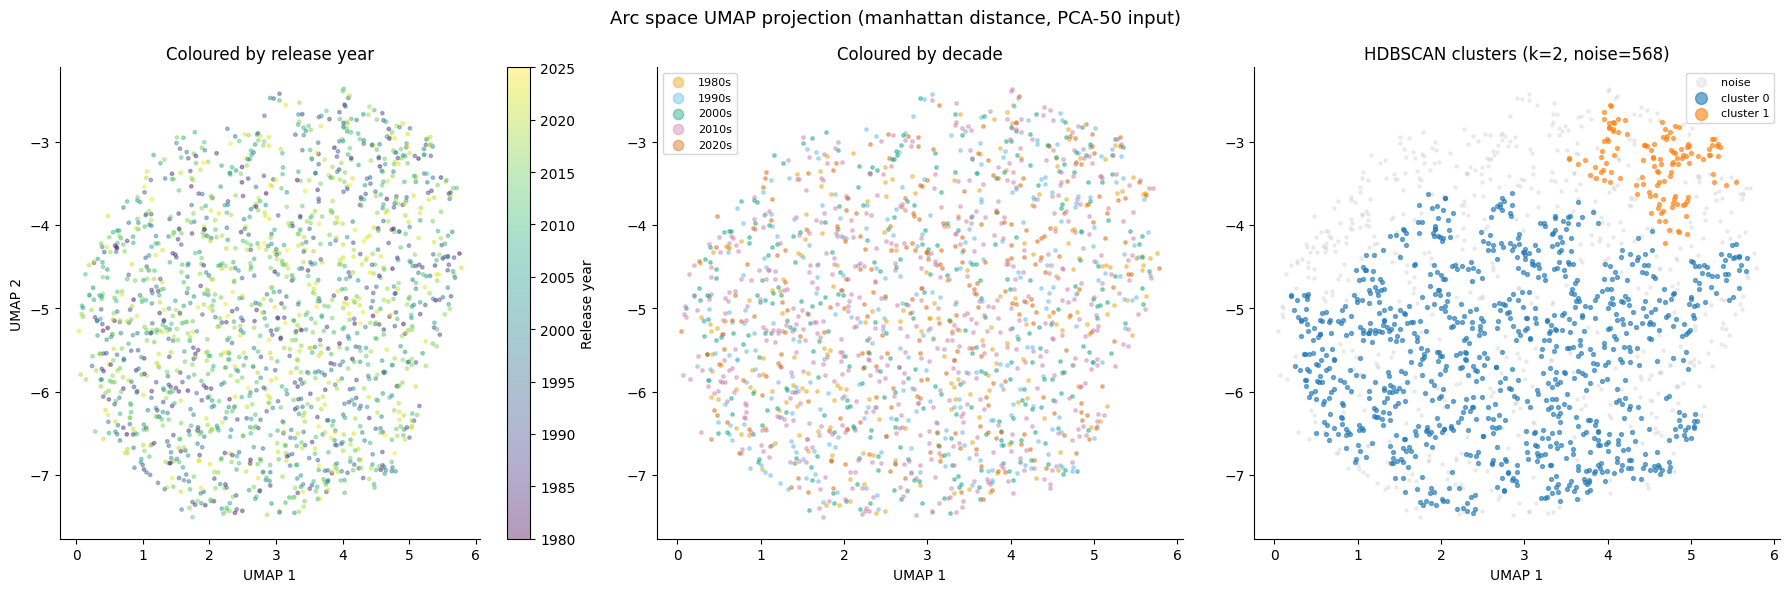

In [19]:
decade_colours = {
    '1980s': '#E69F00', '1990s': '#56B4E9',
    '2000s': '#009E73', '2010s': '#CC79A7', '2020s': '#D55E00'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: colour by year (continuous) ────────────────────────────────────────
sc = axes[0].scatter(
    df['umap_x'], df['umap_y'],
    c=df['year'], cmap='viridis', alpha=0.4, s=6
)
plt.colorbar(sc, ax=axes[0], label='Release year')
axes[0].set_title('Coloured by release year')
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].spines[['top','right']].set_visible(False)

# Panel 2: colour by decade ───────────────────────────────────────────────────
for decade, colour in decade_colours.items():
    mask = df['decade'] == decade
    axes[1].scatter(
        df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
        c=colour, alpha=0.4, s=6, label=decade
    )
axes[1].set_title('Coloured by decade')
axes[1].set_xlabel('UMAP 1')
axes[1].legend(markerscale=3, fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

# Panel 3: colour by HDBSCAN cluster ─────────────────────────────────────────
hdb_palette = sns.color_palette('tab10', n_hdb_clusters)
# noise in grey first
noise_mask = df['hdb_cluster'] == -1
axes[2].scatter(
    df.loc[noise_mask, 'umap_x'], df.loc[noise_mask, 'umap_y'],
    c='#CCCCCC', alpha=0.3, s=5, label='noise'
)
for i in range(n_hdb_clusters):
    mask = df['hdb_cluster'] == i
    axes[2].scatter(
        df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
        c=[hdb_palette[i]], alpha=0.6, s=8, label=f'cluster {i}'
    )
axes[2].set_title(f'HDBSCAN clusters (k={n_hdb_clusters}, noise={n_noise})')
axes[2].set_xlabel('UMAP 1')
axes[2].legend(markerscale=3, fontsize=8)
axes[2].spines[['top','right']].set_visible(False)

fig.suptitle('Arc space UMAP projection (manhattan distance, PCA-50 input)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}umap_arc_space.png', dpi=150, bbox_inches='tight')
plt.show()

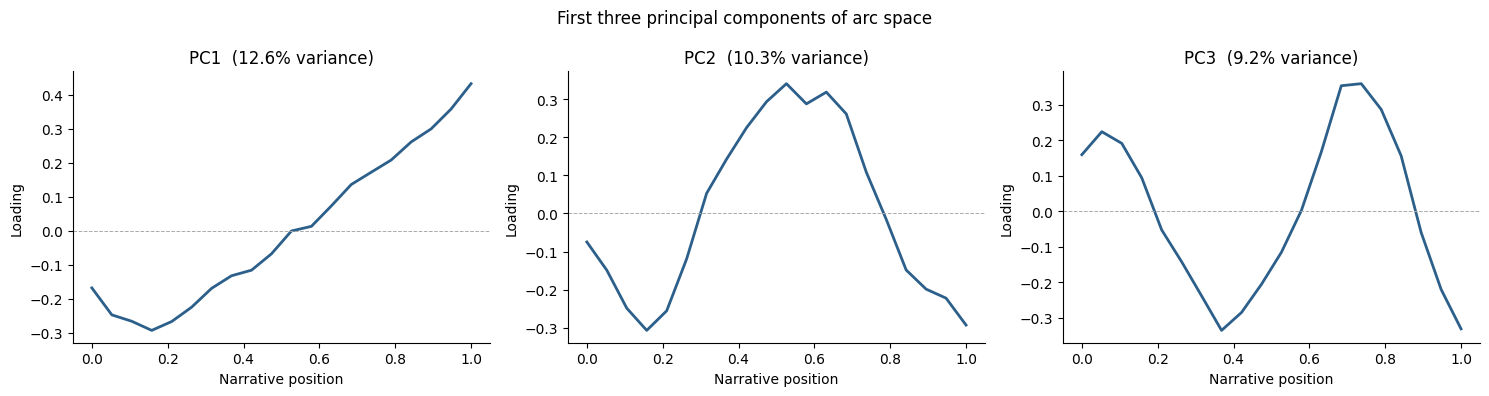

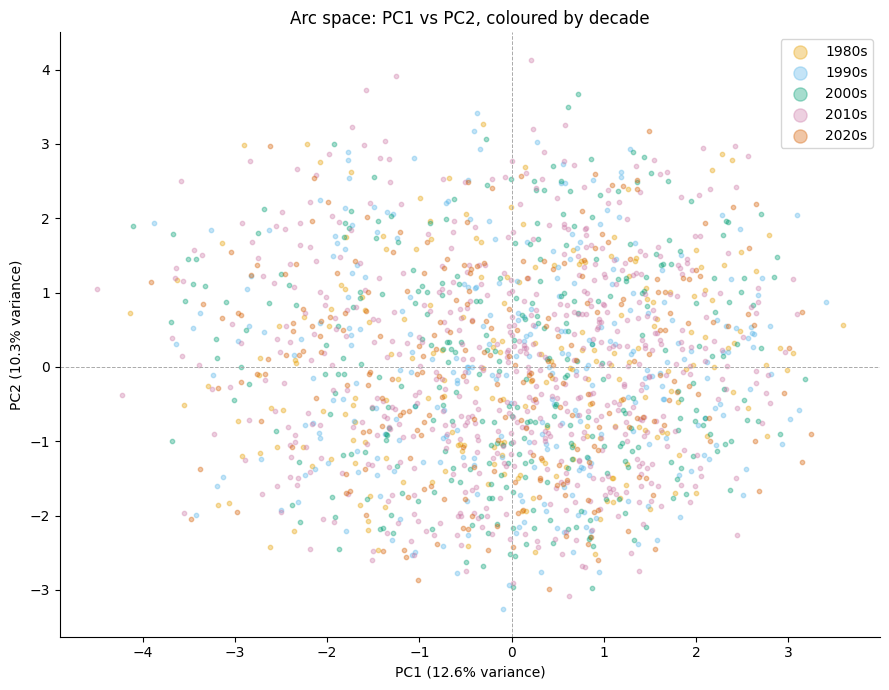

In [20]:
# ── PCA mode inspection ───────────────────────────────────────────────────────
# The first two principal components capture the dominant axes of arc variation.
# PC1 is typically overall valence (positive vs negative arc), PC2 is often
# timing of peak sentiment (early vs late). Plotting them reveals what the
# 'dimensions' of arc space actually are in this corpus.

x_pos = np.linspace(0, 1, 20)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    component = pca_50.components_[i]
    var_pct   = pca_50.explained_variance_ratio_[i] * 100
    axes[i].plot(x_pos, component, color='#2C5F8A', linewidth=2)
    axes[i].axhline(0, color='#AAAAAA', linewidth=0.7, linestyle='--')
    axes[i].set_title(f'PC{i+1}  ({var_pct:.1f}% variance)')
    axes[i].set_xlabel('Narrative position')
    axes[i].set_ylabel('Loading')
    axes[i].spines[['top','right']].set_visible(False)

fig.suptitle('First three principal components of arc space', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}pca_components.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PC1 vs PC2 scatterplot coloured by decade ─────────────────────────────────
pc_scores = pca_50.transform(arc_matrix)   # already computed above

fig, ax = plt.subplots(figsize=(9, 7))
for decade, colour in decade_colours.items():
    mask = df['decade'] == decade
    ax.scatter(pc_scores[mask, 0], pc_scores[mask, 1],
               c=colour, alpha=0.35, s=10, label=decade)

ax.axhline(0, color='#AAAAAA', linewidth=0.7, linestyle='--')
ax.axvline(0, color='#AAAAAA', linewidth=0.7, linestyle='--')
ax.set_xlabel(f"PC1 ({pca_50.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_50.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title('Arc space: PC1 vs PC2, coloured by decade')
ax.legend(markerscale=3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2c: k-Shape Clustering — Pure Shape Families

All previous clustering used point-wise distance: it compared arc value at time-step 1 to arc value at time-step 1, step 2 to step 2, and so on. Two arcs with the same shape but where one peaks slightly earlier will look *distant* under that metric even though they are the same story shape.

k-Shape (Paparrizos & Gravano, 2015) is designed specifically for this question. Its distance measure — Shape-Based Distance (SBD) — uses normalized cross-correlation, which is invariant to the timing and amplitude of the arc. It asks: *same shape?* rather than *same values at same positions?* This is the most appropriate algorithm for the research question: how many distinct narrative shape families exist in this corpus?

Decade and genre play no role here. This section is purely about shape.

In [21]:
import sys
!{sys.executable} -m pip install --quiet tslearn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


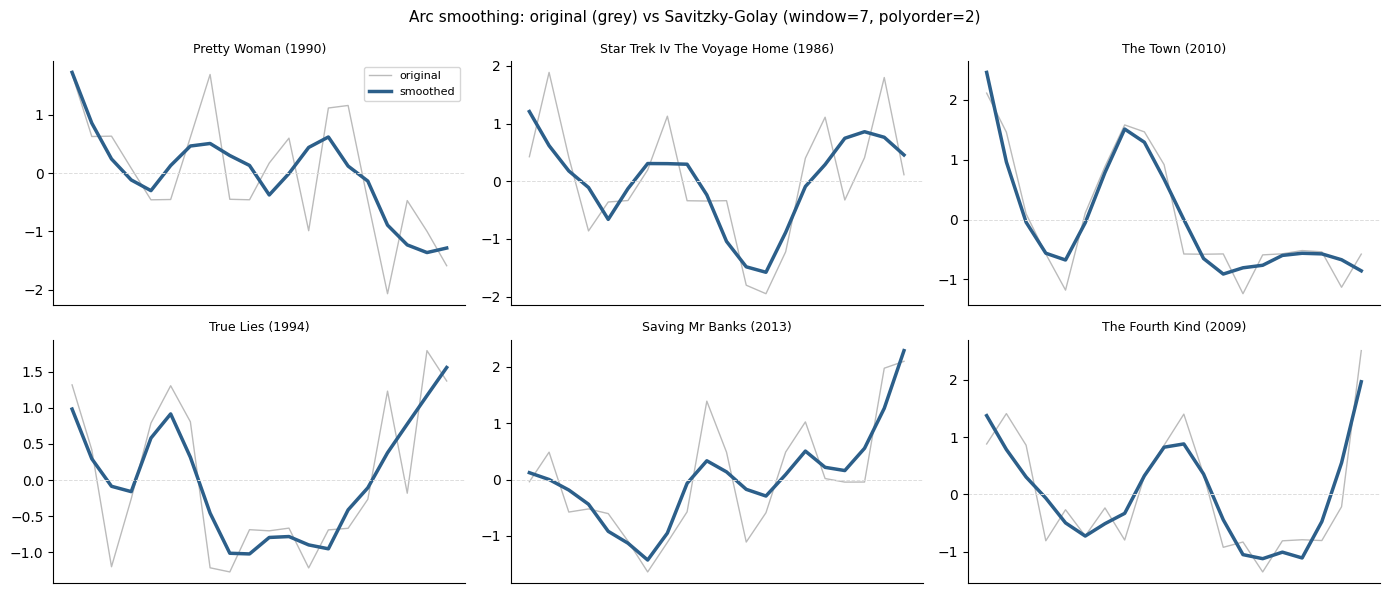

arc_matrix_smooth shape: (1627, 20)
Mean per-arc std  before smoothing: 0.9973
Mean per-arc std  after  smoothing: 0.7461


In [27]:
from scipy.signal import savgol_filter

# ── Apply stronger Savitzky-Golay smoothing to arc vectors ───────────────────
# Reagan et al. used 10,000-word windows which produced inherently smooth arcs.
# Our RoBERTa windows are smaller and noisier. A second smoothing pass reduces
# high-frequency noise so clustering focuses on the overall arc shape, not
# sentence-level sentiment spikes.
#
# window_length=7, polyorder=2: smooths over ~35% of the arc length.
# Increase window_length to 9 or 11 for more aggressive smoothing.
SMOOTH_WINDOW   = 7   # must be odd and < 20
SMOOTH_POLYORDER = 2

arc_matrix_smooth = np.apply_along_axis(
    lambda arc: savgol_filter(arc, window_length=SMOOTH_WINDOW, polyorder=SMOOTH_POLYORDER),
    axis=1,
    arr=arc_matrix
)

# ── Visual comparison: original vs smoothed on 6 random arcs ─────────────────
rng2   = np.random.default_rng(seed=7)
sample = rng2.choice(len(df), size=6, replace=False)
x_pos  = np.linspace(0, 1, 20)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for ax, idx in zip(axes, sample):
    orig   = arc_matrix[idx]
    smooth = arc_matrix_smooth[idx]
    ax.plot(x_pos, orig,   color='#AAAAAA', linewidth=1,   label='original', alpha=0.8)
    ax.plot(x_pos, smooth, color='#2C5F8A', linewidth=2.5, label='smoothed')
    ax.axhline(0, color='#DDDDDD', linewidth=0.7, linestyle='--')
    ax.set_title(f"{df.iloc[idx]['title']} ({int(df.iloc[idx]['year'])})", fontsize=9)
    ax.set_xticks([])
    ax.spines[['top','right']].set_visible(False)

axes[0].legend(fontsize=8)
fig.suptitle(
    f'Arc smoothing: original (grey) vs Savitzky-Golay '
    f'(window={SMOOTH_WINDOW}, polyorder={SMOOTH_POLYORDER})',
    fontsize=11
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}smoothing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'arc_matrix_smooth shape: {arc_matrix_smooth.shape}')
print(f'Mean per-arc std  before smoothing: {arc_matrix.std(axis=1).mean():.4f}')
print(f'Mean per-arc std  after  smoothing: {arc_matrix_smooth.std(axis=1).mean():.4f}')

In [28]:
from tslearn.clustering import KShape
from tslearn.metrics import cdist_soft_dtw
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# tslearn expects shape (n_samples, n_timepoints, 1)
arc_ts = arc_matrix_smooth.reshape(arc_matrix_smooth.shape[0], arc_matrix_smooth.shape[1], 1)

# k-Shape includes its own z-normalisation; our arcs are already z-scored
# but we rescale anyway to satisfy tslearn's internal checks
scaler = TimeSeriesScalerMeanVariance()
arc_ts_scaled = scaler.fit_transform(arc_ts)

# ── Silhouette sweep k=2..10 ─────────────────────────────────────────────────
# SBD doesn't plug directly into sklearn silhouette, so we use Euclidean
# distance on the scaled series as a proxy — consistent across k values.
k_range        = range(2, 11)
kshape_sil     = []
kshape_inertia = []
kshape_models  = {}

arc_2d = arc_ts_scaled.reshape(len(arc_ts_scaled), 20)  # flat for silhouette

print('Fitting k-Shape for k=2..10 (this takes a minute)...')
for k in k_range:
    ks = KShape(n_clusters=k, n_init=5, random_state=42, verbose=False)
    labels = ks.fit_predict(arc_ts_scaled)
    sil    = silhouette_score(arc_2d, labels, metric='euclidean')
    kshape_sil.append(sil)
    kshape_inertia.append(ks.inertia_)
    kshape_models[k] = ks
    print(f'  k={k:2d}  silhouette={sil:.4f}  inertia={ks.inertia_:.2f}')

best_k_kshape = list(k_range)[kshape_sil.index(max(kshape_sil))]
print(f'\nSilhouette peak: k={best_k_kshape}  (score={max(kshape_sil):.4f})')

Fitting k-Shape for k=2..10 (this takes a minute)...
  k= 2  silhouette=0.0479  inertia=0.11
  k= 3  silhouette=0.0362  inertia=0.09
  k= 4  silhouette=0.0180  inertia=0.08
  k= 5  silhouette=0.0031  inertia=0.07
  k= 6  silhouette=-0.0022  inertia=0.06
  k= 7  silhouette=-0.0129  inertia=0.06
  k= 8  silhouette=-0.0145  inertia=0.05
  k= 9  silhouette=-0.0199  inertia=0.05
  k=10  silhouette=-0.0248  inertia=0.05

Silhouette peak: k=2  (score=0.0479)


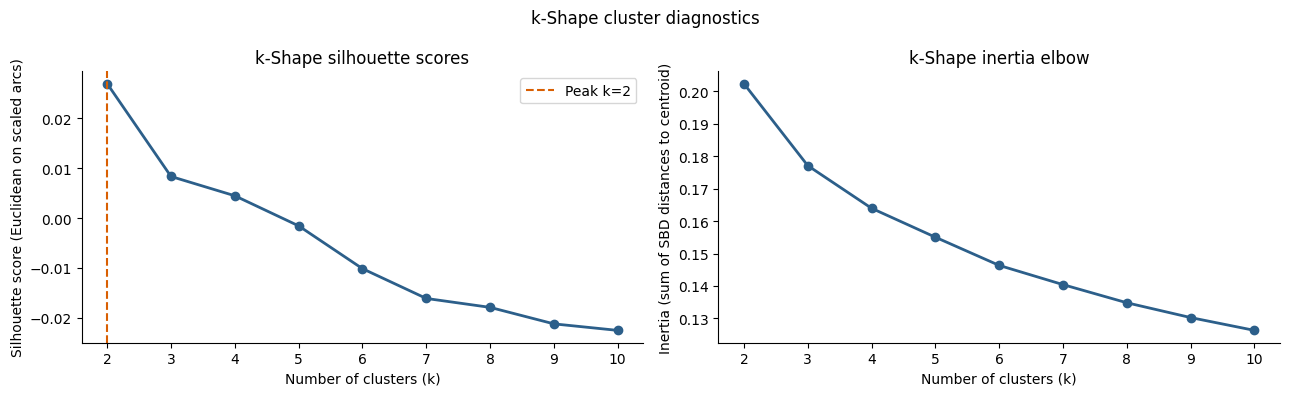

In [23]:
# ── Diagnostic plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), kshape_sil, marker='o', color='#2C5F8A', linewidth=2)
axes[0].axvline(best_k_kshape, color='#D95F02', linestyle='--', linewidth=1.5,
                label=f'Peak k={best_k_kshape}')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Silhouette score (Euclidean on scaled arcs)')
axes[0].set_title('k-Shape silhouette scores')
axes[0].set_xticks(list(k_range))
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(list(k_range), kshape_inertia, marker='o', color='#2C5F8A', linewidth=2)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Inertia (sum of SBD distances to centroid)')
axes[1].set_title('k-Shape inertia elbow')
axes[1].set_xticks(list(k_range))
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('k-Shape cluster diagnostics', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}kshape_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

k-Shape cluster membership (k=2):
  Cluster 0:  838 films (51.5%)
  Cluster 1:  789 films (48.5%)


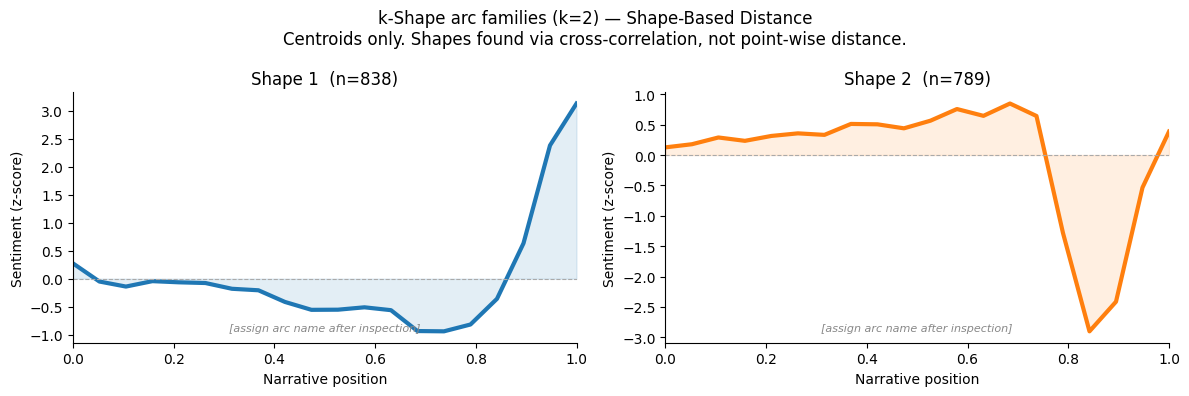

In [24]:
# ── Centroid shapes for best k ────────────────────────────────────────────────
# Change k_final to inspect any k value from the sweep above.
k_final = best_k_kshape

best_model   = kshape_models[k_final]
final_labels = best_model.fit_predict(arc_ts_scaled)
df['kshape_cluster'] = final_labels

print(f'k-Shape cluster membership (k={k_final}):')
for cid in sorted(df['kshape_cluster'].unique()):
    n   = (df['kshape_cluster'] == cid).sum()
    pct = n / len(df) * 100
    print(f'  Cluster {cid}: {n:4d} films ({pct:.1f}%)')

# ── Plot centroids only — no member arc noise ─────────────────────────────────
x_pos    = np.linspace(0, 1, 20)
palette  = sns.color_palette('tab10', k_final)
ncols    = min(k_final, 3)
nrows    = int(np.ceil(k_final / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

for idx in range(k_final):
    ax        = axes[idx // ncols][idx % ncols]
    color     = palette[idx]
    n_members = (final_labels == idx).sum()

    # k-Shape centroid is stored as (n_timepoints, 1)
    centroid = best_model.cluster_centers_[idx].flatten()

    ax.plot(x_pos, centroid, color=color, linewidth=3)
    ax.fill_between(x_pos, centroid, 0, alpha=0.12, color=color)
    ax.axhline(0, color='#AAAAAA', linewidth=0.8, linestyle='--')

    ax.set_title(f'Shape {idx + 1}  (n={n_members})', fontsize=12)
    ax.text(0.5, 0.04, '[assign arc name after inspection]',
            ha='center', va='bottom', transform=ax.transAxes,
            fontsize=8, color='#888888', style='italic')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Narrative position')
    ax.set_ylabel('Sentiment (z-score)')
    ax.spines[['top','right']].set_visible(False)

for idx in range(k_final, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle(
    f'k-Shape arc families (k={k_final}) — Shape-Based Distance\n'
    'Centroids only. Shapes found via cross-correlation, not point-wise distance.',
    fontsize=12
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}kshape_centroids.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ── 10 most central films per k-Shape cluster ─────────────────────────────────
# Distance to centroid: Euclidean between scaled arc and cluster centroid.
from numpy.linalg import norm

centroids_kshape = best_model.cluster_centers_  # (k, 20, 1)

distances = []
for i, row_arc in enumerate(arc_ts_scaled):
    cid  = final_labels[i]
    dist = norm(row_arc.flatten() - centroids_kshape[cid].flatten())
    distances.append(dist)
df['kshape_dist_to_centroid'] = distances

display_cols = ['title', 'year', 'primary_genre', 'kshape_dist_to_centroid']

for cid in sorted(df['kshape_cluster'].unique()):
    cluster_df = df[df['kshape_cluster'] == cid].sort_values('kshape_dist_to_centroid')
    print(f'\n{"="*65}')
    print(f'SHAPE {cid + 1}  —  {len(cluster_df)} films')
    print(f'{"="*65}')
    top10 = cluster_df.head(10)[display_cols].copy()
    top10['kshape_dist_to_centroid'] = top10['kshape_dist_to_centroid'].round(4)
    print(top10.to_string(index=False))


SHAPE 1  —  838 films
                  title  year primary_genre  kshape_dist_to_centroid
                     It  2017        Horror                   2.1822
            Chasing Amy  1997        Comedy                   2.3267
              Emergency  2022        Comedy                   2.3845
              Nine Days  2020         Drama                   2.4392
        Bridge Of Spies  2015      Thriller                   2.7407
       Any Given Sunday  1999         Drama                   2.7477
             Four Rooms  1995        Comedy                   2.8114
Honey I Blew Up The Kid  1992     Adventure                   2.8648
                    Jfk  1991         Drama                   2.8848
The Karate Kid Part Iii  1989        Action                   2.9174

SHAPE 2  —  789 films
                    title  year   primary_genre  kshape_dist_to_centroid
                 Sunshine  2007 Science Fiction                   2.9143
            Almost Famous  2000           Drama  

## Section 2d: Two-Level Clustering

The data supports one robust binary split: films whose sentiment holds or rises across the narrative vs films that fall sharply in the final act. Rather than forcing more clusters onto the full corpus — where the data shows no natural structure beyond k=2 — we use that binary as a first-level partition and then ask, *within each group*, whether finer sub-structure exists.

This two-level approach is methodologically honest: it only claims structure where the data supports it, and the resulting taxonomy is grounded in the data rather than imported from Reagan et al. Each sub-cluster is found independently using k-Shape with shape-based distance on the smoothed arcs.

In [29]:
from tslearn.clustering import KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Use the k=2 result from Section 2c as the top-level split ────────────────
# kshape_models[2] was fitted on arc_matrix_smooth in Section 2c.
# If you re-run this section independently, re-fit k=2 here first.
scaler       = TimeSeriesScalerMeanVariance()
arc_ts_scaled = scaler.fit_transform(
    arc_matrix_smooth.reshape(arc_matrix_smooth.shape[0], arc_matrix_smooth.shape[1], 1)
)

top_model    = KShape(n_clusters=2, n_init=5, random_state=42, verbose=False)
top_labels   = top_model.fit_predict(arc_ts_scaled)
df['top_cluster'] = top_labels

group_sizes = {c: (top_labels == c).sum() for c in [0, 1]}
print('Top-level split (k=2):')
for c, n in group_sizes.items():
    print(f'  Group {c}: {n} films ({n/len(df)*100:.1f}%)')

# ── Sweep k=2..6 within each group ───────────────────────────────────────────
sub_k_range  = range(2, 7)
sub_results  = {}   # group -> {k -> (silhouette, inertia, model)}

for group in [0, 1]:
    mask        = top_labels == group
    group_arcs  = arc_ts_scaled[mask]
    group_flat  = arc_matrix_smooth[mask]   # for silhouette
    sub_results[group] = {}

    print(f'\nGroup {group} (n={mask.sum()}) — sub-clustering sweep:')
    for k in sub_k_range:
        if k >= mask.sum():   # can't have more clusters than members
            break
        ks     = KShape(n_clusters=k, n_init=5, random_state=42, verbose=False)
        labels = ks.fit_predict(group_arcs)
        sil    = silhouette_score(group_flat, labels, metric='euclidean') if len(set(labels)) > 1 else 0.0
        sub_results[group][k] = (sil, ks.inertia_, ks, labels)
        print(f'  k={k}  silhouette={sil:.4f}  inertia={ks.inertia_:.4f}')

Top-level split (k=2):
  Group 0: 795 films (48.9%)
  Group 1: 832 films (51.1%)

Group 0 (n=795) — sub-clustering sweep:
  k=2  silhouette=0.0429  inertia=0.0841
  k=3  silhouette=0.0443  inertia=0.0703
  k=4  silhouette=0.0257  inertia=0.0612
  k=5  silhouette=-0.0044  inertia=0.0577
  k=6  silhouette=-0.0001  inertia=0.0514

Group 1 (n=832) — sub-clustering sweep:
  k=2  silhouette=0.0292  inertia=0.0874
  k=3  silhouette=0.0462  inertia=0.0740
  k=4  silhouette=0.0426  inertia=0.0633
  k=5  silhouette=0.0271  inertia=0.0550
  k=6  silhouette=0.0256  inertia=0.0505


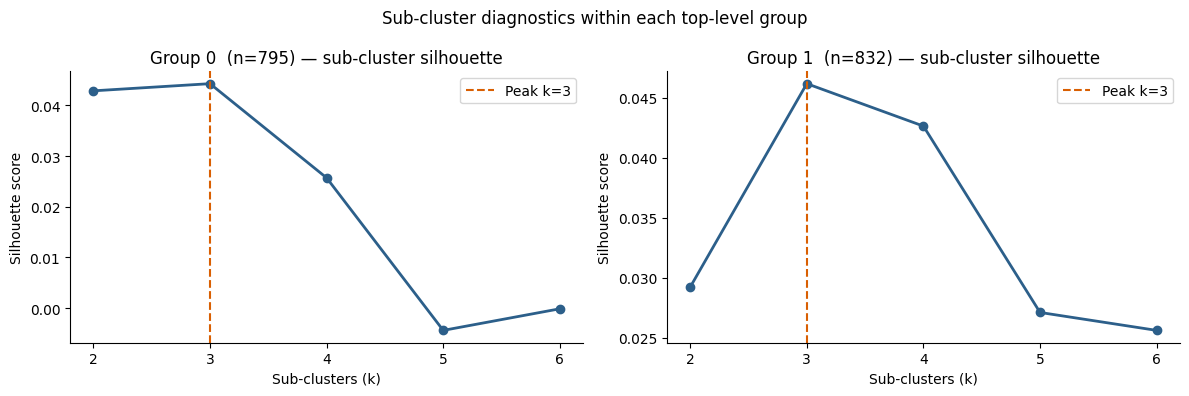

In [30]:
# ── Silhouette plots for each group ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for group in [0, 1]:
    ax      = axes[group]
    ks_vals = list(sub_results[group].keys())
    sils    = [sub_results[group][k][0] for k in ks_vals]
    best_k  = ks_vals[sils.index(max(sils))]

    ax.plot(ks_vals, sils, marker='o', color='#2C5F8A', linewidth=2)
    ax.axvline(best_k, color='#D95F02', linestyle='--', linewidth=1.5,
               label=f'Peak k={best_k}')
    ax.set_title(f'Group {group}  (n={group_sizes[group]}) — sub-cluster silhouette')
    ax.set_xlabel('Sub-clusters (k)')
    ax.set_ylabel('Silhouette score')
    ax.set_xticks(ks_vals)
    ax.legend()
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle('Sub-cluster diagnostics within each top-level group', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}subcluster_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ── Parameters: choose sub-k for each group after inspecting diagnostics ──────
# Default: silhouette peak from the sweep. Override manually if the shapes
# at a neighbouring k are more interpretively distinct.
sub_k = {
    0: max(sub_results[0], key=lambda k: sub_results[0][k][0]),
    1: max(sub_results[1], key=lambda k: sub_results[1][k][0]),
}
print(f'Using sub-k: Group 0 → k={sub_k[0]},  Group 1 → k={sub_k[1]}')
total_clusters = sub_k[0] + sub_k[1]
print(f'Total arc families: {total_clusters}')

# ── Assign final global cluster labels ───────────────────────────────────────
df['arc_cluster'] = -1
cluster_counter   = 0
cluster_meta      = []   # records centroid shape, group, sub-label

x_pos = np.linspace(0, 1, 20)

for group in [0, 1]:
    mask        = (top_labels == group)
    _, _, model, sub_labels = sub_results[group][sub_k[group]]
    centroids_raw = model.cluster_centers_   # (sub_k, 20, 1)

    for sub_id in range(sub_k[group]):
        global_id   = cluster_counter
        member_mask = mask.copy()
        member_mask[mask] = (sub_labels == sub_id)
        df.loc[member_mask, 'arc_cluster'] = global_id
        centroid_arc = centroids_raw[sub_id].flatten()
        cluster_meta.append({
            'arc_cluster': global_id,
            'top_group':   group,
            'sub_id':      sub_id,
            'n_films':     member_mask.sum(),
            'centroid':    centroid_arc,
        })
        cluster_counter += 1

print('\nFinal cluster membership:')
for meta in cluster_meta:
    pct = meta['n_films'] / len(df) * 100
    print(f"  Cluster {meta['arc_cluster']}  (group {meta['top_group']}, sub {meta['sub_id']}): "
          f"{meta['n_films']} films ({pct:.1f}%)")

Using sub-k: Group 0 → k=3,  Group 1 → k=3
Total arc families: 6

Final cluster membership:
  Cluster 0  (group 0, sub 0): 226 films (13.9%)
  Cluster 1  (group 0, sub 1): 257 films (15.8%)
  Cluster 2  (group 0, sub 2): 312 films (19.2%)
  Cluster 3  (group 1, sub 0): 415 films (25.5%)
  Cluster 4  (group 1, sub 1): 136 films (8.4%)
  Cluster 5  (group 1, sub 2): 281 films (17.3%)


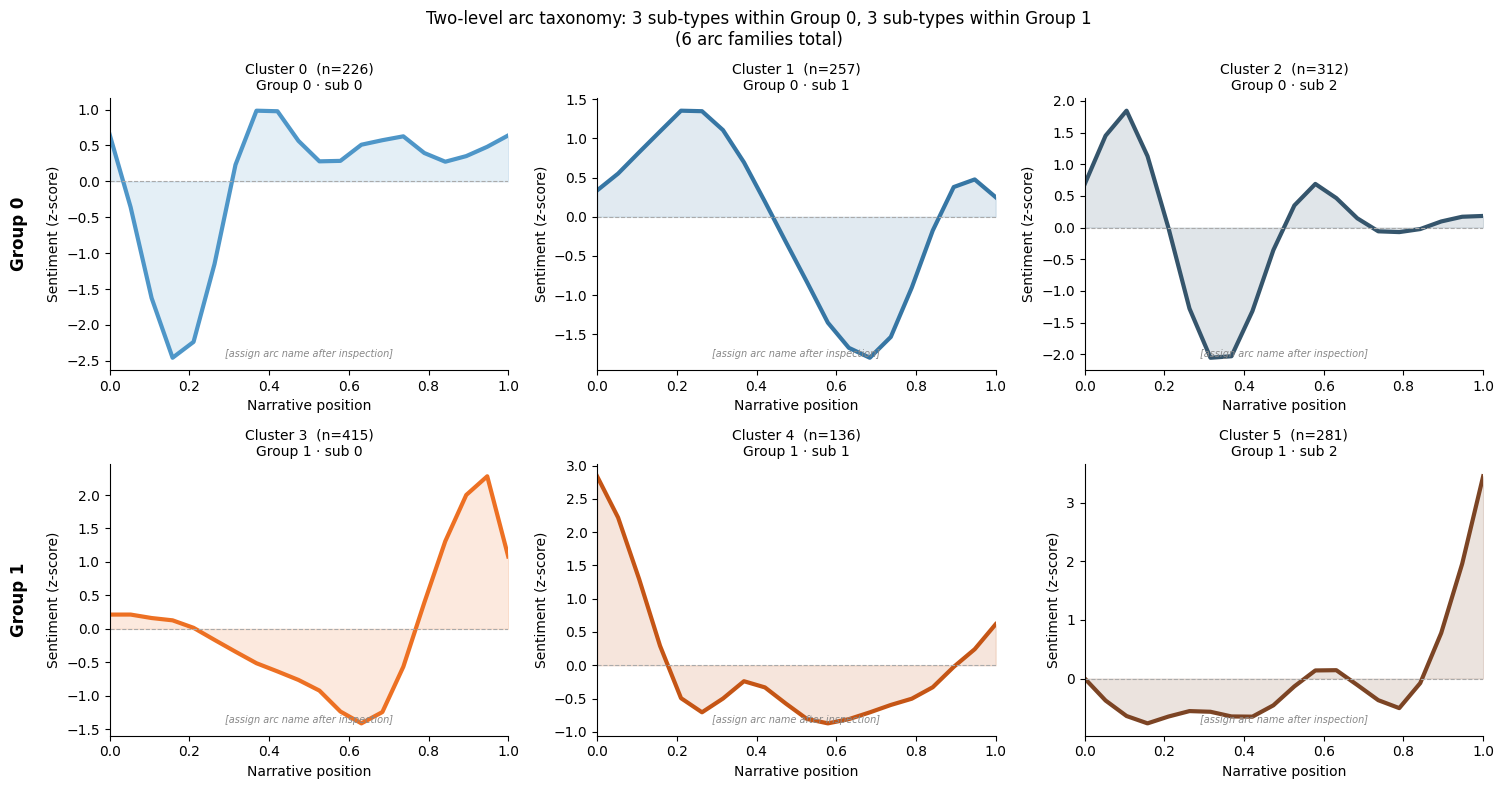

In [32]:
# ── Plot all final centroids ──────────────────────────────────────────────────
# Clusters from Group 0 and Group 1 are visually separated by row.
n_g0    = sub_k[0]
n_g1    = sub_k[1]
n_cols  = max(n_g0, n_g1)
palette_g0 = sns.color_palette('Blues_d',  n_g0 + 1)[1:]
palette_g1 = sns.color_palette('Oranges_d', n_g1 + 1)[1:]

fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 8))
if n_cols == 1:
    axes = axes.reshape(2, 1)

for meta in cluster_meta:
    row     = meta['top_group']
    col     = meta['sub_id']
    ax      = axes[row][col]
    color   = (palette_g0 if row == 0 else palette_g1)[col]

    ax.plot(x_pos, meta['centroid'], color=color, linewidth=3)
    ax.fill_between(x_pos, meta['centroid'], 0, alpha=0.15, color=color)
    ax.axhline(0, color='#AAAAAA', linewidth=0.8, linestyle='--')
    ax.set_title(
        f"Cluster {meta['arc_cluster']}  (n={meta['n_films']})\n"
        f"Group {meta['top_group']} · sub {meta['sub_id']}",
        fontsize=10
    )
    ax.text(0.5, 0.04, '[assign arc name after inspection]',
            ha='center', va='bottom', transform=ax.transAxes,
            fontsize=7, color='#888888', style='italic')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Narrative position')
    ax.set_ylabel('Sentiment (z-score)')
    ax.spines[['top','right']].set_visible(False)

# Hide unused panels
for row in [0, 1]:
    n_used = sub_k[row]
    for col in range(n_used, n_cols):
        axes[row][col].set_visible(False)

# Row labels
axes[0][0].annotate('Group 0', xy=(-0.25, 0.5), xycoords='axes fraction',
                    fontsize=12, fontweight='bold', rotation=90, va='center')
axes[1][0].annotate('Group 1', xy=(-0.25, 0.5), xycoords='axes fraction',
                    fontsize=12, fontweight='bold', rotation=90, va='center')

fig.suptitle(
    f'Two-level arc taxonomy: {n_g0} sub-types within Group 0, '
    f'{n_g1} sub-types within Group 1\n'
    f'({total_clusters} arc families total)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}twolevel_centroids.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── Most central films per final cluster ──────────────────────────────────────
from numpy.linalg import norm

# Rebuild per-film distance to its final centroid
centroid_lookup = {meta['arc_cluster']: meta['centroid'] for meta in cluster_meta}

def dist_to_final_centroid(row):
    cid      = int(row['arc_cluster'])
    arc_vals = arc_matrix_smooth[row.name]
    return norm(arc_vals - centroid_lookup[cid])

df['arc_dist_to_centroid'] = df.apply(dist_to_final_centroid, axis=1)

display_cols = ['title', 'year', 'primary_genre', 'arc_dist_to_centroid']

for meta in cluster_meta:
    cid        = meta['arc_cluster']
    cluster_df = df[df['arc_cluster'] == cid].sort_values('arc_dist_to_centroid')
    print(f'\n{"="*65}')
    print(f"CLUSTER {cid}  (Group {meta['top_group']}, sub {meta['sub_id']})  —  {meta['n_films']} films")
    print(f'{"="*65}')
    top10 = cluster_df.head(10)[display_cols].copy()
    top10['arc_dist_to_centroid'] = top10['arc_dist_to_centroid'].round(4)
    print(top10.to_string(index=False))


CLUSTER 0  (Group 0, sub 0)  —  226 films
                                          title  year   primary_genre  arc_dist_to_centroid
                                        Warrior  2011           Drama                1.4236
                        Ferris Buellers Day Off  1986          Comedy                1.4508
Pirates Of The Caribbean Dead Men Tell No Tales  2017       Adventure                1.7205
                                         Pixels  2015          Action                1.8117
                                        Krampus  2015          Horror                1.9043
                                   Last Holiday  2006       Adventure                2.0282
                                The Incredibles  2004          Action                2.0360
                              Battlefield Earth  2000 Science Fiction                2.1885
     Fantastic Beasts The Secrets Of Dumbledore  2022         Fantasy                2.2640
                         Lars And The

## Section 3: Hierarchical Clustering

We use agglomerative hierarchical clustering with Ward's linkage criterion. Ward's method merges clusters in the way that minimises the increase in total within-cluster variance at each step — it tends to produce compact, roughly equal-sized clusters. The dendrogram below is a tree diagram showing the full merge history of the corpus. The vertical height of each merge represents how dissimilar the two groups being joined were. Long vertical lines signal meaningful structure; many short merges at a similar height suggest a natural "floor" where clusters stabilise. This is the visual equivalent of Reagan et al. Figure 5.

Linkage matrix shape: (1626, 4)  (1626 merge steps for 1627 films)


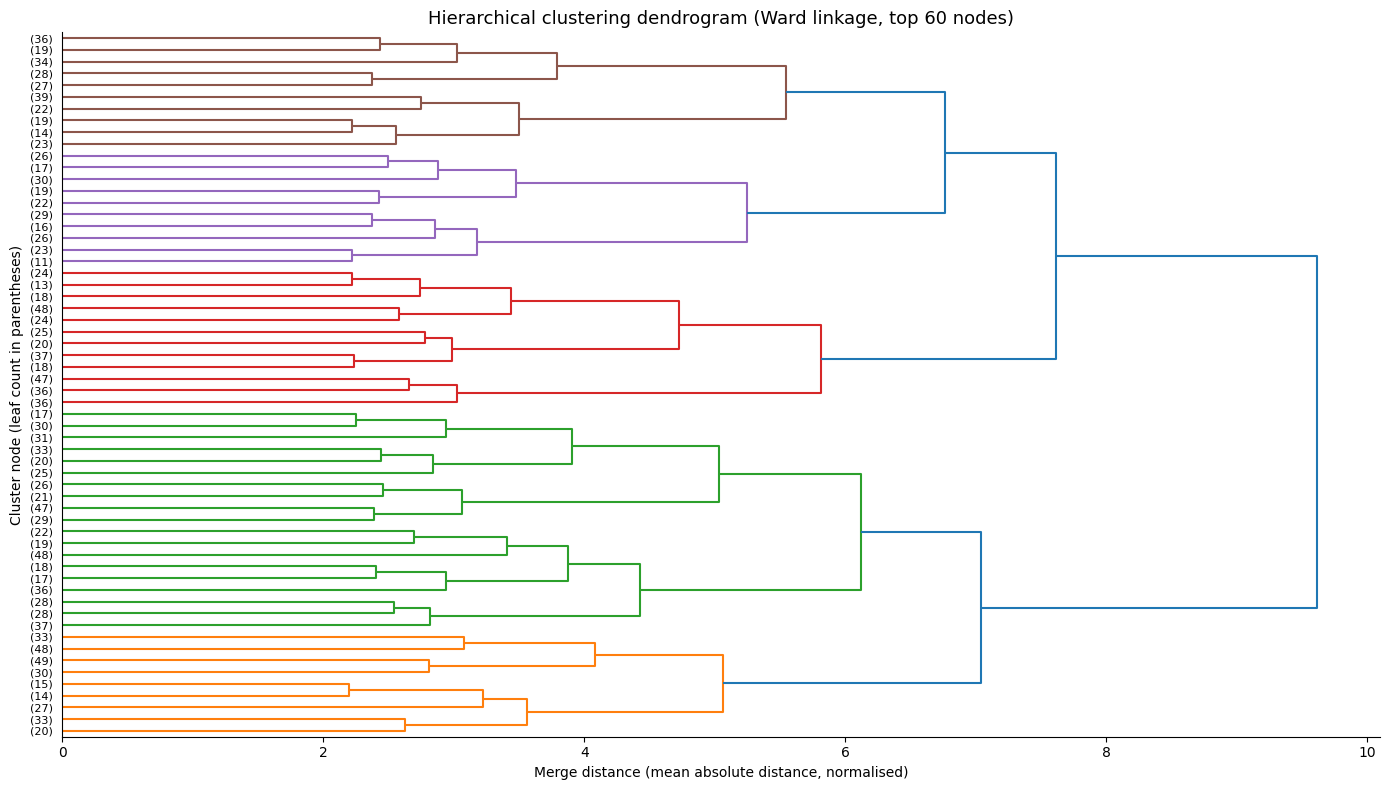

In [7]:
# Ward linkage requires the condensed distance matrix
Z = linkage(condensed_mad, method="ward")

print(f"Linkage matrix shape: {Z.shape}  ({Z.shape[0]} merge steps for {len(df)} films)")

# ── dendrogram ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

dendrogram(
    Z,
    ax=ax,
    truncate_mode="lastp",
    p=60,
    orientation="right",
    show_leaf_counts=True,
    leaf_font_size=8,
    color_threshold=0.7 * max(Z[:, 2]),
)

ax.set_title("Hierarchical clustering dendrogram (Ward linkage, top 60 nodes)", fontsize=13)
ax.set_xlabel("Merge distance (mean absolute distance, normalised)")
ax.set_ylabel("Cluster node (leaf count in parentheses)")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4: Determine Number of Clusters

The dendrogram suggests a rough structure, but we need a more principled way to choose k — the number of arc families we will work with. Three complementary diagnostics are shown together below:

1. **Silhouette score** measures how well each film fits its assigned cluster versus the nearest alternative cluster. Higher is better; values above 0.5 indicate clear separation.
2. **Merge distance elbow** shows how much additional dissimilarity is absorbed at each merge step. A sharp elbow suggests the merges below it are meaningful; the merges above collapse distinct groups.
3. **Summary heatmap** combines both metrics across k=2–12 on the same colour scale so trade-offs are visible at a glance.

The recommended k from the silhouette peak is printed below the figure. However, the final k should be chosen after also considering the dendrogram structure (Section 3) and the qualitative interpretability of the centroid shapes (Section 5). Reagan et al. found six arc types; starting with k=6 is a reasonable default.

Silhouette peak at k=2  (score=0.0441)


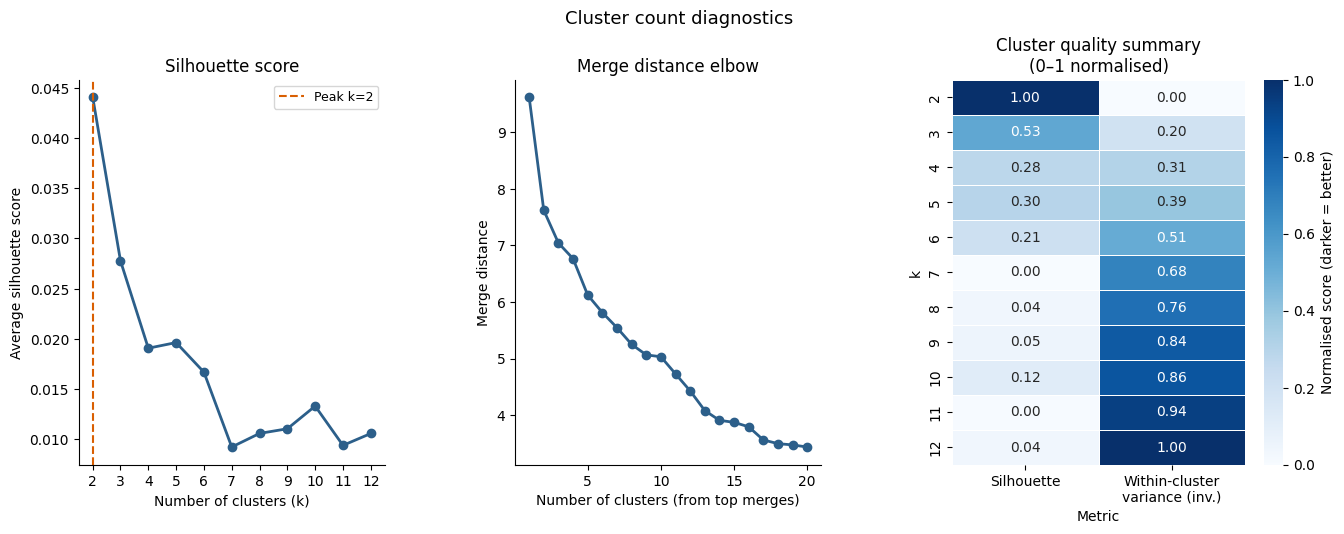


Recommended k from silhouette peak: 2


In [8]:
k_range = range(2, 13)

silhouette_scores   = []
within_cluster_vars = []

for k in k_range:
    labels = fcluster(Z, k, criterion="maxclust")

    sil = silhouette_score(dist_matrix, labels, metric="precomputed")
    silhouette_scores.append(sil)

    # Within-cluster variance: mean of per-cluster arc vector variances
    wcv = 0.0
    for cluster_id in np.unique(labels):
        members = arc_matrix[labels == cluster_id]
        wcv += members.var(axis=0).mean()
    within_cluster_vars.append(wcv / k)

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"Silhouette peak at k={best_k}  (score={max(silhouette_scores):.4f})")

# ── three-panel diagnostic figure ────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.4)

# Panel 1: silhouette scores
ax1 = fig.add_subplot(gs[0])
ax1.plot(list(k_range), silhouette_scores, marker="o", color="#2C5F8A", linewidth=2)
ax1.axvline(best_k, color="#D95F02", linestyle="--", linewidth=1.5, label=f"Peak k={best_k}")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Average silhouette score")
ax1.set_title("Silhouette score")
ax1.set_xticks(list(k_range))
ax1.legend(fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)

# Panel 2: merge distance elbow
ax2 = fig.add_subplot(gs[1])
last_20_merges = Z[-20:, 2][::-1]          # reversed: large k → small k
n_clusters_axis = np.arange(1, 21)
ax2.plot(n_clusters_axis, last_20_merges, marker="o", color="#2C5F8A", linewidth=2)
ax2.set_xlabel("Number of clusters (from top merges)")
ax2.set_ylabel("Merge distance")
ax2.set_title("Merge distance elbow")
ax2.spines[["top", "right"]].set_visible(False)

# Panel 3: summary heatmap
ax3 = fig.add_subplot(gs[2])

def normalise_01(values):
    arr = np.array(values, dtype=float)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

sil_norm = normalise_01(silhouette_scores)
wcv_norm = 1 - normalise_01(within_cluster_vars)  # invert: lower variance = better

heatmap_data = pd.DataFrame({
    "Silhouette": sil_norm,
    "Within-cluster\nvariance (inv.)": wcv_norm,
}, index=list(k_range))

sns.heatmap(
    heatmap_data,
    ax=ax3,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Normalised score (darker = better)"},
    vmin=0, vmax=1,
)
ax3.set_xlabel("Metric")
ax3.set_ylabel("k")
ax3.set_title("Cluster quality summary\n(0–1 normalised)")

fig.suptitle("Cluster count diagnostics", fontsize=13, y=1.02)
plt.savefig(f"{OUTPUT_DIR}cluster_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nRecommended k from silhouette peak: {best_k}")

> **Researcher note:** The k recommended above is a data-driven starting point. Before committing to a final k, inspect the dendrogram (Section 3) for natural cut heights and look at the centroid shapes in Section 5. Reagan et al. used k=6, which maps onto Vonnegut's six arc types. If the silhouette peak is at a different k, consider whether the additional clusters are substantively distinct or merely splitting noise. The final choice should be defensible on both statistical and interpretive grounds.

## Section 5: Extract Clusters and Plot Centroids

With k chosen, we cut the dendrogram at the level that produces exactly k clusters and compute the centroid — the average arc shape — for each cluster. The centroid is the representative "platonic form" of that arc family. Plotting centroids side by side is the key interpretive step: this is where the researcher names the arc types. The names come from Vonnegut's and Reagan et al.'s vocabulary (Rags to Riches, Tragedy, Man in a Hole, Icarus, Cinderella, Oedipus) but are assigned by looking at the shapes, not by algorithm. Placeholder labels are included in each panel.

Cluster membership counts:
  Cluster 1:  269 films (16.5%)
  Cluster 2:  253 films (15.6%)
  Cluster 3:  279 films (17.1%)
  Cluster 4:  346 films (21.3%)
  Cluster 5:  219 films (13.5%)
  Cluster 6:  261 films (16.0%)


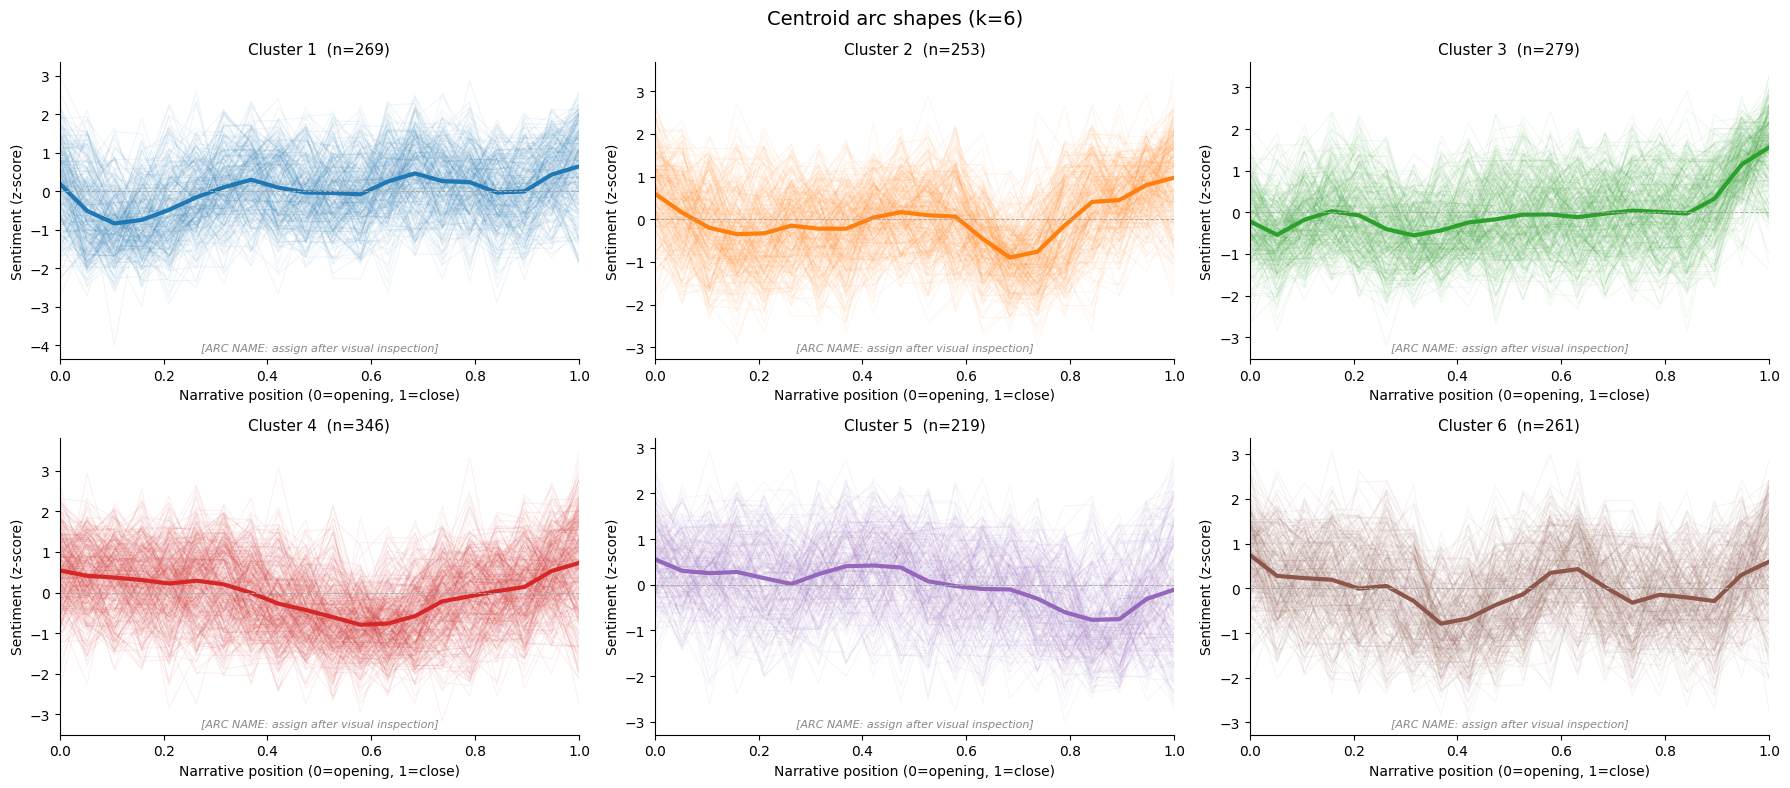

In [9]:
# ── parameter: set k here ────────────────────────────────────────────────────
# Change this value after inspecting the diagnostics in Section 4.
# Default is 6 to match Reagan et al.'s six arc types.
k = 6

# ── extract flat cluster assignments ─────────────────────────────────────────
cluster_labels = fcluster(Z, k, criterion="maxclust")
df["cluster_id"] = cluster_labels

print("Cluster membership counts:")
for cid in sorted(df["cluster_id"].unique()):
    count = (df["cluster_id"] == cid).sum()
    pct   = count / len(df) * 100
    print(f"  Cluster {cid}: {count:4d} films ({pct:.1f}%)")

# ── compute centroids ─────────────────────────────────────────────────────────
cluster_ids = sorted(df["cluster_id"].unique())
centroids   = {}   # cluster_id → np.ndarray of shape (20,)

for cid in cluster_ids:
    members = df[df["cluster_id"] == cid][ARC_COLS].values.astype(float)
    centroids[cid] = members.mean(axis=0)

# ── plot centroid arcs ────────────────────────────────────────────────────────
# Arc names are assigned MANUALLY by the researcher after visual inspection.
# Vonnegut / Reagan et al. vocabulary: Rags to Riches, Tragedy, Man in a Hole,
# Icarus, Cinderella, Oedipus. Do not assign programmatically.
arc_name_placeholders = {cid: "[ARC NAME: assign after visual inspection]" for cid in cluster_ids}

ncols = min(k, 3)
nrows = int(np.ceil(k / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

x_positions = np.linspace(0, 1, 20)
palette     = sns.color_palette("tab10", k)

for idx, cid in enumerate(cluster_ids):
    ax    = axes[idx // ncols][idx % ncols]
    color = palette[idx]
    count = (df["cluster_id"] == cid).sum()

    # Plot all member arcs faintly in the background
    members = df[df["cluster_id"] == cid][ARC_COLS].values.astype(float)
    for member_arc in members:
        ax.plot(x_positions, member_arc, color=color, alpha=0.07, linewidth=0.8)

    # Plot centroid in bold
    ax.plot(x_positions, centroids[cid], color=color, linewidth=3, label="Centroid")
    ax.axhline(0, color="#AAAAAA", linewidth=0.7, linestyle="--")

    ax.set_title(f"Cluster {cid}  (n={count})", fontsize=11, pad=6)
    ax.text(
        0.5, 0.02, arc_name_placeholders[cid],
        ha="center", va="bottom", transform=ax.transAxes,
        fontsize=8, color="#888888", style="italic"
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel("Narrative position (0=opening, 1=close)")
    ax.set_ylabel("Sentiment (z-score)")
    ax.spines[["top", "right"]].set_visible(False)

# Hide any unused subplot panels
for idx in range(len(cluster_ids), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle(f"Centroid arc shapes (k={k})", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}cluster_centroids.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 6: Cluster Membership and Most Central Films

For each cluster we identify the films closest to the centroid — the most archetypal representatives of that arc shape — and the films farthest from it, which sit at the edge of the cluster and share properties with neighbouring arc families. The 10 most central films per cluster are the equivalent of Reagan et al.'s "characteristic stories." Inspecting them is a key part of validating whether the cluster labels make sense: if a cluster labelled "Tragedy" is full of rom-coms, something is off.

In [10]:
from numpy.linalg import norm

# Euclidean distance from each film to its cluster centroid
def distance_to_centroid(row, centroid_arc):
    return norm(row[ARC_COLS].values.astype(float) - centroid_arc)

df["dist_to_centroid"] = df.apply(
    lambda row: distance_to_centroid(row, centroids[row["cluster_id"]]),
    axis=1
)

display_cols = ["title", "year", "decade", "primary_genre", "dist_to_centroid"]

for cid in cluster_ids:
    cluster_df = df[df["cluster_id"] == cid].copy()
    sorted_df  = cluster_df.sort_values("dist_to_centroid")

    print(f"\n{'='*70}")
    print(f"CLUSTER {cid}  —  {len(cluster_df)} films")
    print(f"{'='*70}")

    print("\n  10 most central films (most representative of arc shape):")
    central_films = sorted_df.head(10)[display_cols].copy()
    central_films["dist_to_centroid"] = central_films["dist_to_centroid"].round(4)
    print(central_films.to_string(index=False))

    print("\n  5 most peripheral films (borderline cases):")
    peripheral_films = sorted_df.tail(5)[display_cols].copy()
    peripheral_films["dist_to_centroid"] = peripheral_films["dist_to_centroid"].round(4)
    print(peripheral_films.to_string(index=False))


CLUSTER 1  —  269 films

  10 most central films (most representative of arc shape):
                                          title  year decade primary_genre  dist_to_centroid
                  Never Rarely Sometimes Always  2020  2020s         Drama            2.9754
Pirates Of The Caribbean Dead Men Tell No Tales  2017  2010s     Adventure            3.1751
                                  Love Actually  2003  2000s        Comedy            3.2130
                                 The Red Turtle  2016  2010s     Animation            3.2723
                  Home Alone 2 Lost In New York  1992  1990s        Comedy            3.2896
                                Blades Of Glory  2007  2000s        Comedy            3.2960
                       Kiss Of The Spider Woman  1985  1980s         Drama            3.3126
                                         Living  2022  2020s         Drama            3.3274
                                         Flight  2012  2010s         Drama   

## Section 7: Decade Distribution

This is the core of the research question. If the shapes of Hollywood stories have shifted over time, we should see uneven distributions of arc families across decades — some shapes becoming more common, others fading. We look at this two ways: (1) as a grouped bar chart showing what proportion of each decade's films fall into each cluster, and (2) as year distributions within each cluster, using continuous release year rather than decade bins to avoid the arbitrariness of era cuts.

A chi-square test of independence checks whether the cluster x decade distribution could plausibly have arisen by chance. The standardised residuals identify which specific decade-cluster cells are driving any significant result — those cells are where the historically interesting shifts are happening.

In [11]:
decade_order = ["1980s", "1990s", "2000s", "2010s", "2020s"]

# ── contingency table: rows = clusters, columns = decades ────────────────────
contingency = pd.crosstab(df["cluster_id"], df["decade"])[decade_order]

# Percentage of each decade's films in each cluster
decade_totals = contingency.sum(axis=0)
pct_of_decade = contingency.div(decade_totals, axis=1) * 100

print("Cluster × decade counts:")
print(contingency)
print("\nCluster × decade (% of decade total):")
print(pct_of_decade.round(1))

Cluster × decade counts:
decade      1980s  1990s  2000s  2010s  2020s
cluster_id                                   
1              34     47     62     93     33
2              37     37     49     82     48
3              46     53     46    100     34
4              41     58     69    127     51
5              27     41     39     79     33
6              29     51     45     88     48

Cluster × decade (% of decade total):
decade      1980s  1990s  2000s  2010s  2020s
cluster_id                                   
1            15.9   16.4   20.0   16.3   13.4
2            17.3   12.9   15.8   14.4   19.4
3            21.5   18.5   14.8   17.6   13.8
4            19.2   20.2   22.3   22.3   20.6
5            12.6   14.3   12.6   13.9   13.4
6            13.6   17.8   14.5   15.5   19.4


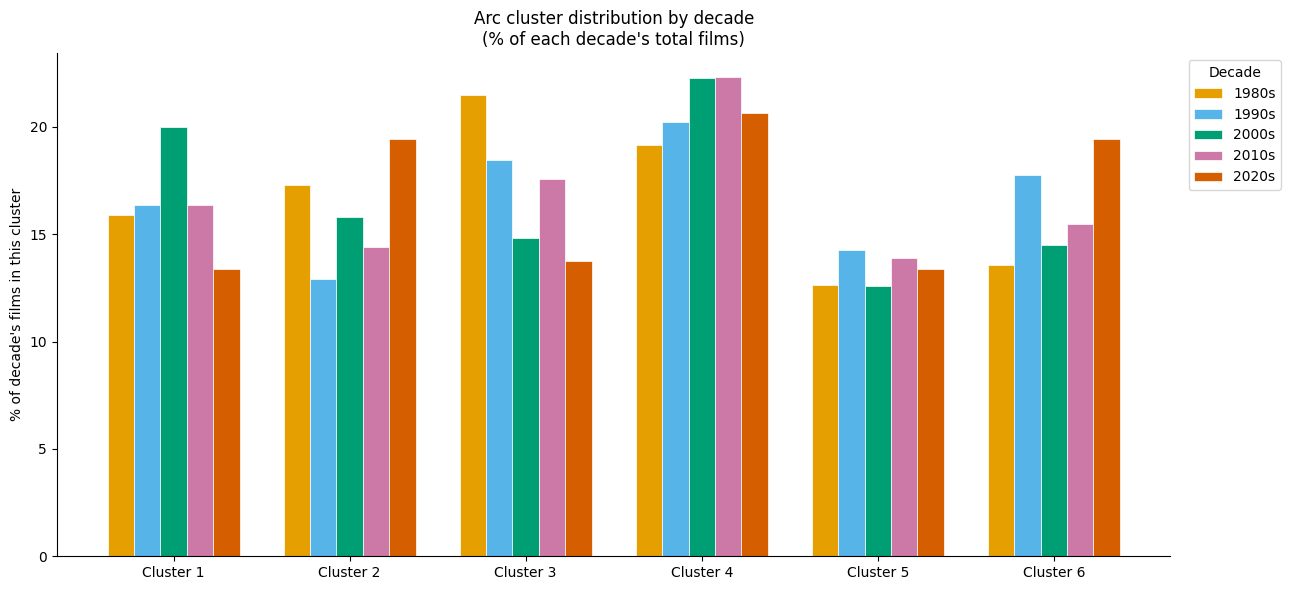

In [12]:
# ── grouped bar chart ─────────────────────────────────────────────────────────
decade_palette = {
    "1980s": "#E69F00",
    "1990s": "#56B4E9",
    "2000s": "#009E73",
    "2010s": "#CC79A7",
    "2020s": "#D55E00",
}

fig, ax = plt.subplots(figsize=(13, 6))

n_clusters = len(cluster_ids)
n_decades  = len(decade_order)
bar_width  = 0.15
x_base     = np.arange(n_clusters)

for i, decade in enumerate(decade_order):
    offsets = x_base + (i - n_decades / 2 + 0.5) * bar_width
    values  = [pct_of_decade.loc[cid, decade] if decade in pct_of_decade.columns else 0
               for cid in cluster_ids]
    ax.bar(offsets, values, width=bar_width, label=decade,
           color=decade_palette[decade], edgecolor="white", linewidth=0.5)

ax.set_xticks(x_base)
ax.set_xticklabels([f"Cluster {cid}" for cid in cluster_ids])
ax.set_ylabel("% of decade's films in this cluster")
ax.set_title("Arc cluster distribution by decade\n(% of each decade's total films)")
ax.legend(title="Decade", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}cluster_decade_barchart.png", dpi=150, bbox_inches="tight")
plt.show()

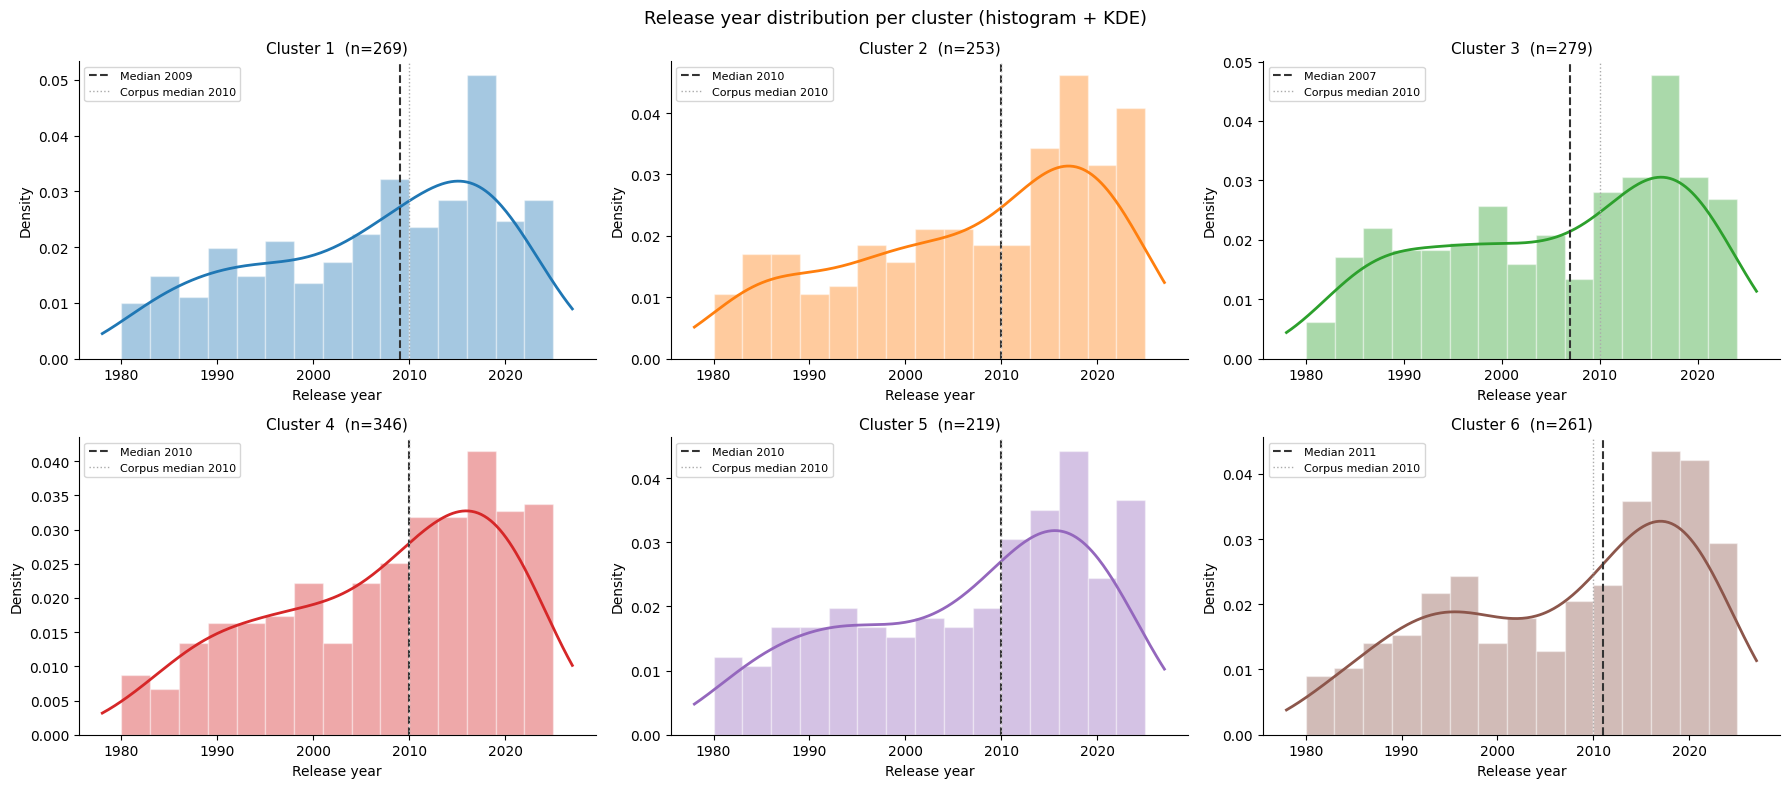


Year distribution summary per cluster:
 cluster_id  n_films  median_year  mean_year  iqr_low  iqr_high
          1      269       2009.0     2006.3     1996      2016
          2      253       2010.0     2007.1     1997      2018
          3      279       2007.0     2005.7     1995      2017
          4      346       2010.0     2007.3     1998      2018
          5      219       2010.0     2006.5     1996      2017
          6      261       2011.0     2007.1     1996      2018


In [13]:
from scipy.stats import gaussian_kde

# ── continuous year distributions per cluster ─────────────────────────────────
corpus_median_year = df["year"].median()

ncols = min(k, 3)
nrows = int(np.ceil(k / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

year_summary_rows = []

for idx, cid in enumerate(cluster_ids):
    ax      = axes[idx // ncols][idx % ncols]
    years   = df[df["cluster_id"] == cid]["year"].values.astype(float)
    color   = palette[idx]

    median_year = np.median(years)
    mean_year   = np.mean(years)
    q25, q75    = np.percentile(years, [25, 75])

    year_summary_rows.append({
        "cluster_id": cid,
        "n_films":    len(years),
        "median_year": round(median_year, 1),
        "mean_year":   round(mean_year, 1),
        "iqr_low":     int(q25),
        "iqr_high":    int(q75),
    })

    ax.hist(years, bins=15, color=color, alpha=0.4, edgecolor="white", density=True)

    # KDE overlay (only if enough points)
    if len(years) > 3:
        kde     = gaussian_kde(years, bw_method=0.4)
        x_range = np.linspace(years.min() - 2, years.max() + 2, 300)
        ax.plot(x_range, kde(x_range), color=color, linewidth=2)

    ax.axvline(median_year, color="#333333", linewidth=1.5, linestyle="--",
               label=f"Median {int(median_year)}")
    ax.axvline(corpus_median_year, color="#AAAAAA", linewidth=1, linestyle=":",
               label=f"Corpus median {int(corpus_median_year)}")

    ax.set_title(f"Cluster {cid}  (n={len(years)})", fontsize=11)
    ax.set_xlabel("Release year")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

for idx in range(len(cluster_ids), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("Release year distribution per cluster (histogram + KDE)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}cluster_year_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

year_summary_df = pd.DataFrame(year_summary_rows)
print("\nYear distribution summary per cluster:")
print(year_summary_df.to_string(index=False))

# Flag clusters with notable temporal skew
for _, row in year_summary_df.iterrows():
    diff = row["median_year"] - corpus_median_year
    if abs(diff) > 5:
        direction = "later" if diff > 0 else "earlier"
        print(f"  ⚑  Cluster {int(row['cluster_id'])} median year {direction} than corpus "
              f"by {abs(diff):.1f} years — worth noting in thesis.")

Chi-square test: cluster × decade independence
  Chi-square statistic : 19.0507
  Degrees of freedom   : 20
  p-value              : 5.1853e-01
  Interpretation: No statistically significant relationship between arc cluster and decade (p ≥ 0.05). Any observed variation may be sampling noise.

Standardised residuals (|value| > 2.0 = statistically meaningful cell):
decade      1980s  1990s  2000s  2010s  2020s
cluster_id                                   
1           -0.23  -0.07   1.50  -0.11  -1.23
2            0.65  -1.14   0.11  -0.69   1.55
3            1.54   0.54  -0.98   0.25  -1.28
4           -0.67  -0.39   0.38   0.55  -0.21
5           -0.34   0.38  -0.42   0.28  -0.04
6           -0.91   0.73  -0.67  -0.34   1.33


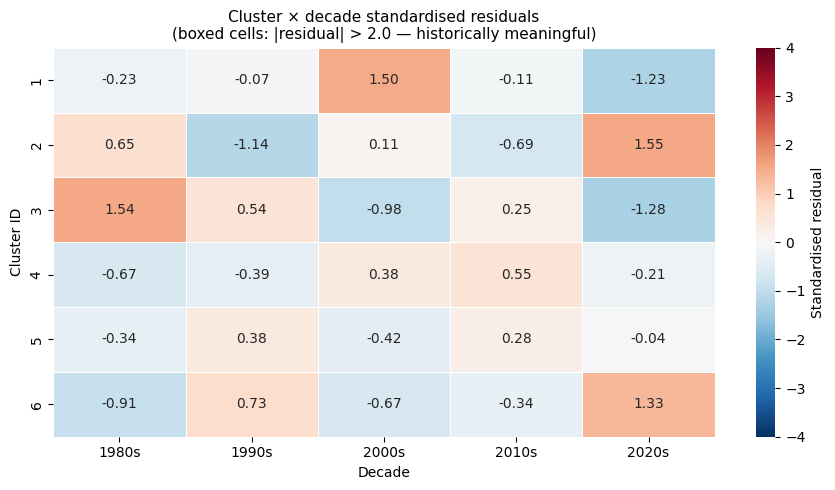

In [14]:
# ── chi-square test of independence ──────────────────────────────────────────
chi2, p_chi2, dof, expected = chi2_contingency(contingency)

print("Chi-square test: cluster × decade independence")
print(f"  Chi-square statistic : {chi2:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  p-value              : {p_chi2:.4e}")
if p_chi2 < 0.05:
    print("  Interpretation: The distribution of arc clusters across decades is "
          "statistically non-uniform (p < 0.05). Some arc shapes are significantly "
          "more or less common in certain decades than chance would predict.")
else:
    print("  Interpretation: No statistically significant relationship between arc "
          "cluster and decade (p ≥ 0.05). Any observed variation may be sampling noise.")

# ── standardised residuals ────────────────────────────────────────────────────
# Standardised residual = (observed - expected) / sqrt(expected)
# |residual| > 2.0 indicates a cell driving significance.
observed_array = contingency.values.astype(float)
std_residuals  = (observed_array - expected) / np.sqrt(expected)
residuals_df   = pd.DataFrame(
    std_residuals,
    index=contingency.index,
    columns=contingency.columns
)

print("\nStandardised residuals (|value| > 2.0 = statistically meaningful cell):")
print(residuals_df.round(2))

# ── residuals heatmap ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    residuals_df,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Standardised residual"},
    vmin=-4, vmax=4,
)

# Highlight cells where |residual| > 2.0
for row_idx in range(residuals_df.shape[0]):
    for col_idx in range(residuals_df.shape[1]):
        if abs(residuals_df.iloc[row_idx, col_idx]) > 2.0:
            ax.add_patch(plt.Rectangle(
                (col_idx, row_idx), 1, 1,
                fill=False, edgecolor="black", linewidth=2
            ))

ax.set_title(
    "Cluster × decade standardised residuals\n"
    "(boxed cells: |residual| > 2.0 — historically meaningful)",
    fontsize=11
)
ax.set_xlabel("Decade")
ax.set_ylabel("Cluster ID")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}cluster_decade_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 8: Genre Distribution Within Clusters

Genre is not a clustering variable — the arc families were found purely from sentiment shape. But looking at how genre maps onto the clusters helps interpret what they mean. A cluster dominated by action films probably looks different from one dominated by dramas, and that contrast clarifies what the arc shape is actually capturing. This section explodes multi-genre tags so each film can contribute to all its genres, then plots genre composition per cluster as a heatmap and as stacked bar charts broken down by decade.

> **Note:** Because genre tags overlap (a film can be Drama *and* Thriller), all counts here are film-genre pairings, not distinct film counts. A single film can appear in multiple genre bars.

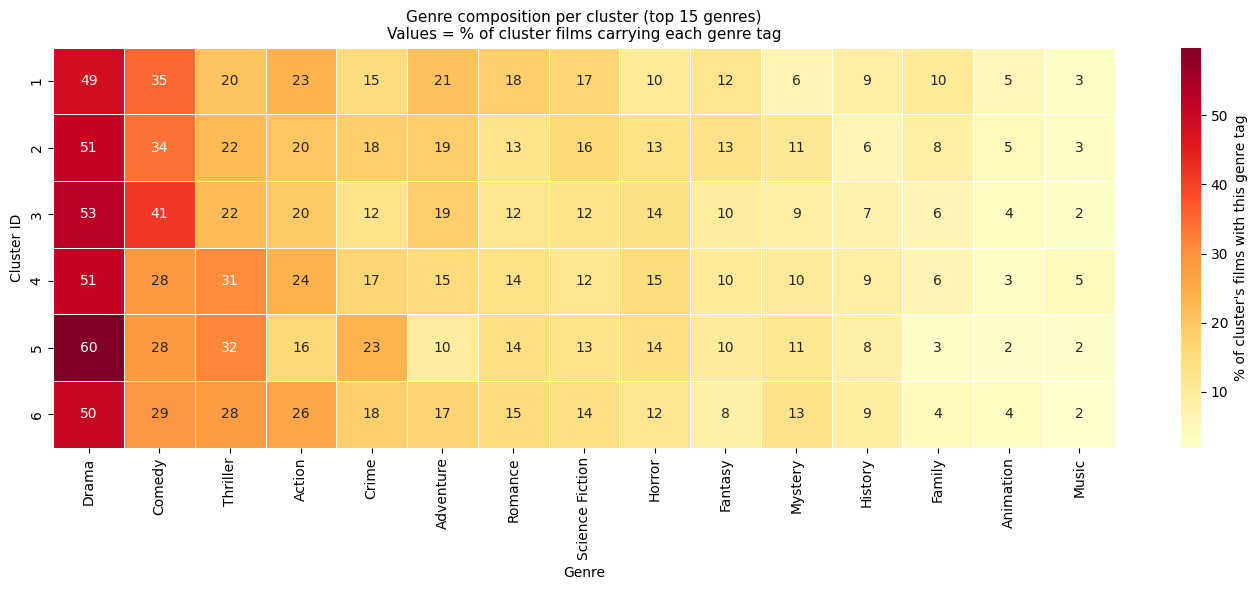

In [15]:
# ── explode pipe-separated genres ─────────────────────────────────────────────
df_exploded = df.assign(genre=df["genre"].str.split("|")).explode("genre")
df_exploded["genre"] = df_exploded["genre"].str.strip()

# Top 15 genres across the full corpus
top_genres = df_exploded["genre"].value_counts().head(15).index.tolist()

# ── genre × cluster heatmap ───────────────────────────────────────────────────
# For each cluster: % of that cluster's films carrying each genre tag
genre_cluster_pct = {}
for cid in cluster_ids:
    cluster_size   = (df["cluster_id"] == cid).sum()
    cluster_genres = df_exploded[df_exploded["cluster_id"] == cid]["genre"]
    genre_counts   = cluster_genres.value_counts()
    pct_row = {g: round(genre_counts.get(g, 0) / cluster_size * 100, 1)
               for g in top_genres}
    genre_cluster_pct[cid] = pct_row

genre_heatmap_df = pd.DataFrame(genre_cluster_pct, columns=cluster_ids).T
genre_heatmap_df.index.name = "cluster_id"

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    genre_heatmap_df,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "% of cluster's films with this genre tag"},
)
ax.set_title(
    "Genre composition per cluster (top 15 genres)\n"
    "Values = % of cluster films carrying each genre tag",
    fontsize=11
)
ax.set_xlabel("Genre")
ax.set_ylabel("Cluster ID")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}cluster_genre_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

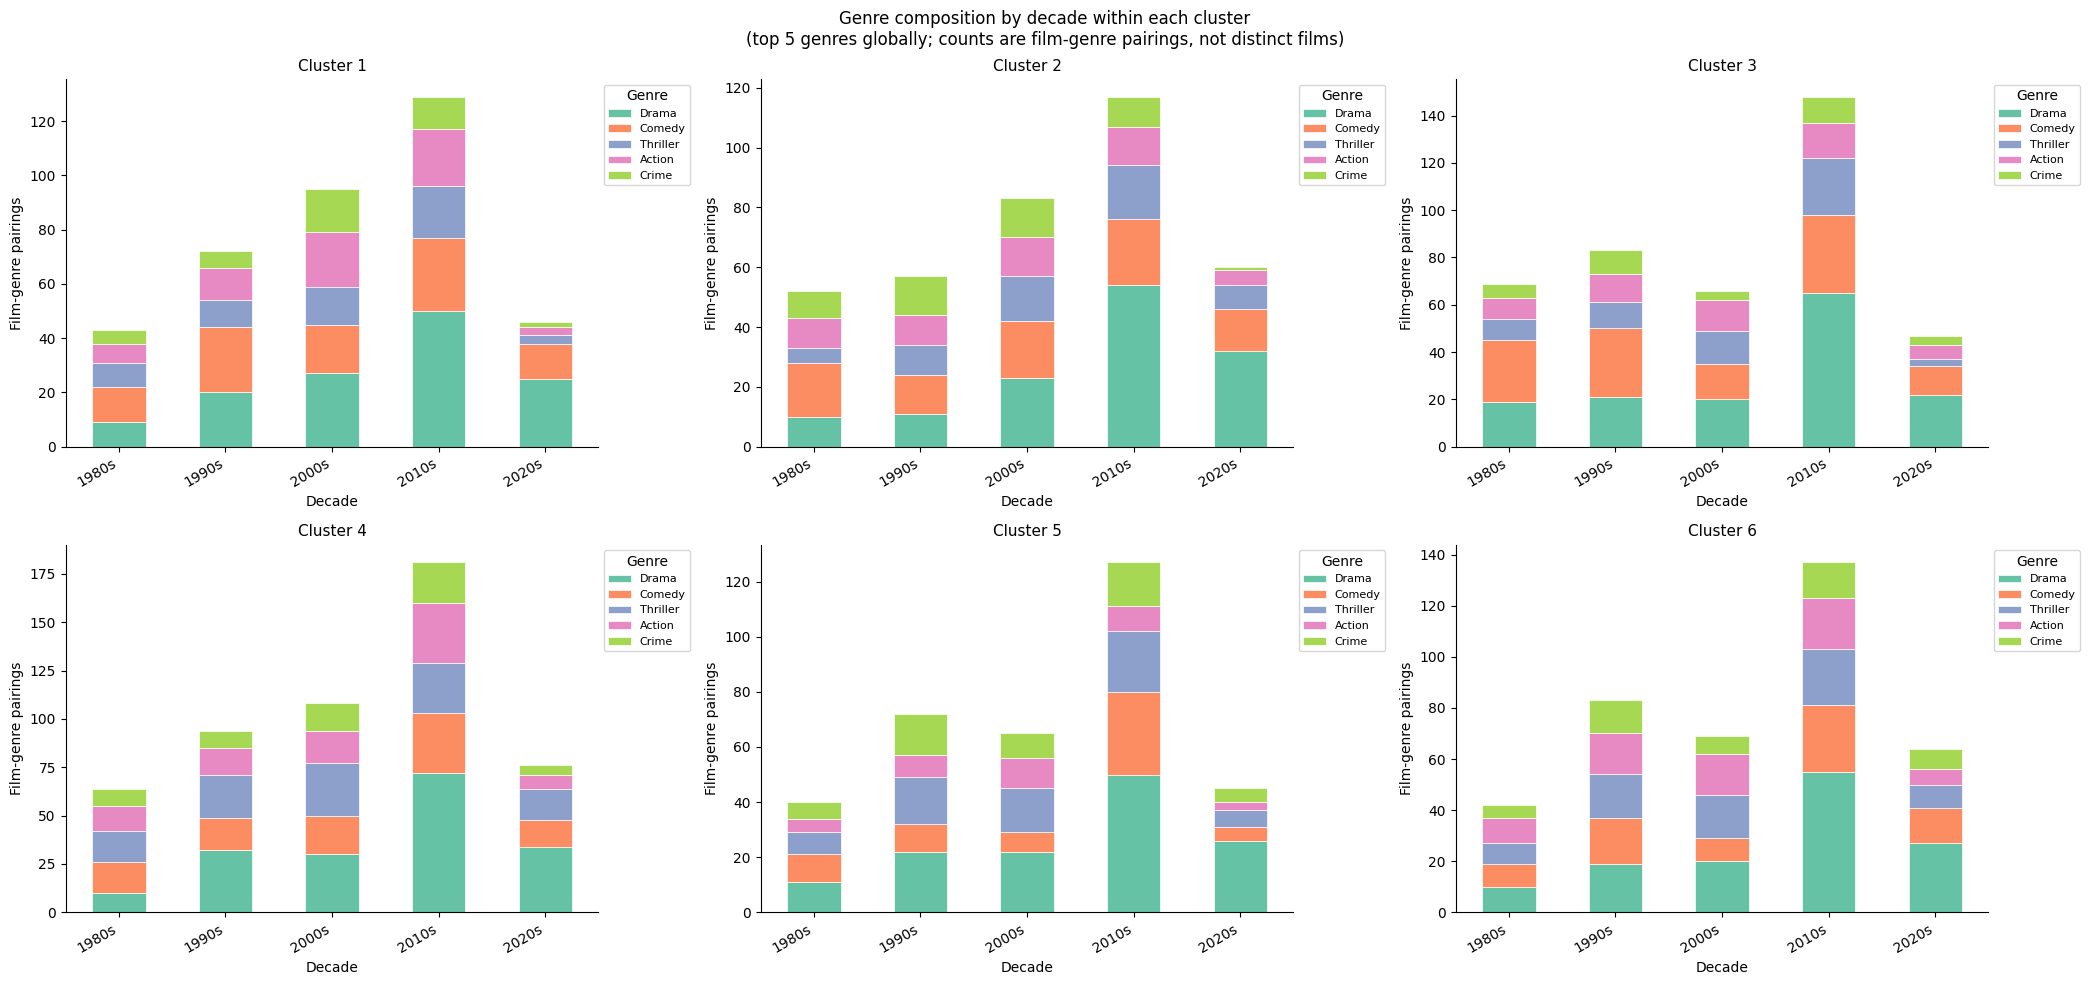

In [16]:
# ── genre composition by decade within each cluster ───────────────────────────
# For each cluster, stacked bar: x=decade, stacked bars=top genres
top5_genres_global = df_exploded["genre"].value_counts().head(5).index.tolist()

ncols = min(k, 3)
nrows = int(np.ceil(k / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False)

genre_palette = sns.color_palette("Set2", len(top5_genres_global))

for idx, cid in enumerate(cluster_ids):
    ax = axes[idx // ncols][idx % ncols]

    cluster_exploded = df_exploded[
        (df_exploded["cluster_id"] == cid) &
        (df_exploded["genre"].isin(top5_genres_global))
    ]

    genre_decade = (
        cluster_exploded.groupby(["decade", "genre"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=decade_order, fill_value=0)
        .reindex(columns=top5_genres_global, fill_value=0)
    )

    genre_decade.plot(
        kind="bar", stacked=True, ax=ax,
        color=genre_palette, edgecolor="white", linewidth=0.5
    )

    ax.set_title(f"Cluster {cid}", fontsize=11)
    ax.set_xlabel("Decade")
    ax.set_ylabel("Film-genre pairings")
    ax.set_xticklabels(decade_order, rotation=30, ha="right")
    ax.legend(title="Genre", fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
    ax.spines[["top", "right"]].set_visible(False)

for idx in range(len(cluster_ids), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle(
    "Genre composition by decade within each cluster\n"
    "(top 5 genres globally; counts are film-genre pairings, not distinct films)",
    fontsize=12
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}cluster_genre_decade_stacked.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 9: Export

All outputs are written to the `thesis-outputs/` directory. The clustered dataframe is the primary output for downstream analysis and case study work. The centroid file has placeholder arc names — fill these in manually after visual inspection before citing them in the thesis.

In [ ]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. full dataframe with cluster assignments ────────────────────────────────
df.to_csv(f"{OUTPUT_DIR}emotional_arcs_clustered.csv", index=False)
print(f"Saved: emotional_arcs_clustered.csv  ({len(df)} rows)")

# ── 2. cluster centroids ──────────────────────────────────────────────────────
centroid_rows = []
for cid in cluster_ids:
    cluster_subset = df[df["cluster_id"] == cid]
    row = {
        "cluster_id":  cid,
        "arc_name":    "",   # fill in manually after visual inspection
        "film_count":  len(cluster_subset),
        "median_year": cluster_subset["year"].median(),
    }
    for j, col in enumerate(ARC_COLS):
        row[col] = centroids[cid][j]
    centroid_rows.append(row)

centroids_df = pd.DataFrame(centroid_rows)
centroids_df.to_csv(f"{OUTPUT_DIR}cluster_centroids.csv", index=False)
print(f"Saved: cluster_centroids.csv  ({len(centroids_df)} clusters)")

# ── 3. cluster × decade contingency table ────────────────────────────────────
contingency.to_csv(f"{OUTPUT_DIR}cluster_decade_counts.csv")
print(f"Saved: cluster_decade_counts.csv  ({contingency.shape})")

# ── 4. standardised residuals ─────────────────────────────────────────────────
residuals_df.to_csv(f"{OUTPUT_DIR}cluster_decade_residuals.csv")
print(f"Saved: cluster_decade_residuals.csv  ({residuals_df.shape})")

print("\nAll exports complete.")
print(f"  arc_name column in cluster_centroids.csv is blank — assign manually "
      f"after inspecting Section 5 centroid plots.")